## Trial 5 Two Models: Deep3DCNN and CXRClassifier

Two specialized models are trained independently on their respective dataset types:

| Model | Datasets | Rationale |
|---|---|---|
| **Deep3DCNN** (~3.5 M params) | NoduleMNIST3D · LUNA16 | Genuine 3D volumetric CT patches requiring deep spatial feature extraction |
| **CXRClassifier** (~11.2 M params, ResNet-18) | Chest X-ray (CXR) | 2D pretrained backbone; 224×224 grayscale input; fine-tuned for low-resource screening |

**Other changes from Trial 5:**
- LUNA16 preprocessing fixed: percentile-based normalization now matches NoduleMNIST3D
- Label smoothing (ε=0.05) on Deep3DCNN loss
- Deep3DCNN dropout 0.4→0.5; extra residual stage added
- Per-dataset threshold tuning preserved for both models
- Model files split: `src/model3d_deep.py` and `src/model3d_small.py`

In [1]:
import os
import json
import sys
import itertools
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, ConcatDataset

import medmnist
from medmnist import INFO

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve as sk_roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NOTEBOOK_DIR = os.getcwd()

if os.path.basename(NOTEBOOK_DIR) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
else:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

RESULTS_ROOT = os.path.join(REPO_ROOT, "results")
TRIAL_NUM = "06"
RUN_ID    = f"Trial{TRIAL_NUM}_{datetime.now().strftime('%Y-%m-%d_%H.%M.%S')}"
RUN_DIR   = os.path.join(RESULTS_ROOT, "runs", RUN_ID)
FIG_DIR   = os.path.join(RUN_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print("Saving run to:", RUN_DIR)

# ── Trial 6: patch resolution for 3D models ──────────────────────────────────
# NoduleMNIST3D ships at 28³. Trilinear upsampling to 32³ in the collate function
# gives the network a slightly larger spatial feature map at every stage
# (28→ 14→ 7→ 3 becomes 32→ 16→ 8→ 4), providing one extra pooling step of context.
# LUNA16 patches are extracted directly at this size.
PATCH_SIZE = 32

# Dedicated model files
from src.model3d_deep  import Deep3DCNN
from src.model_cxr     import CXRClassifier
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from src.train_utils import (TrainConfig, set_seed, train_one_epoch,
                              evaluate, evaluate_loss, save_json, save_checkpoint,
                              calibrate_temperature)
from src.dataset_utils import ChestXrayCancerDataset, make_cxr_splits, LUNA16Dataset
from src.metrics import compute_binary_metrics, sigmoid

metrics_path = os.path.join(RUN_DIR, "metrics.json")


Saving run to: /Users/toriav/Desktop/Erem/CMPE 401/lung-nodule-3d/results/runs/Trial06_2026-04-13_19.45.27


## Config and device

In [2]:
cfg = TrainConfig(
    epochs=50,
    lr=3e-4,
    weight_decay=1e-4,
    batch_size=128,
    num_workers=0,
    seed=42,
    threshold=0.5,
    scheduler_patience=6,
)

LABEL_SMOOTHING     = 0.05   # for Deep3DCNN BCE loss
EARLY_STOP_PATIENCE = 10

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
set_seed(cfg.seed)
os.makedirs("results/figures", exist_ok=True)


device: cpu


## Load NoduleMNIST3D

In [3]:
data_flag = "nodulemnist3d"
info = INFO[data_flag]

# Dataset class name is stored as a string in INFO; fetch the class object
DataClass = getattr(medmnist, info["python_class"])

print("Task:", info["task"])
print("Labels:", info["label"])
print("Channels:", info["n_channels"])

# Some MedMNIST versions omit n_classes; fallback to the number of labels
n_classes = info.get("n_classes", len(info["label"]))
print("Num classes:", n_classes)

Task: binary-class
Labels: {'0': 'benign', '1': 'malignant'}
Channels: 1
Num classes: 2


## Dataset Splitting

In [4]:
# MedMNIST downloads automatically to its cache location when download=True
train_ds = DataClass(split="train", download=True)
val_ds   = DataClass(split="val", download=True)
test_ds  = DataClass(split="test", download=True)

# Quick check - dataset sizes should match expected counts
print("sizes:", len(train_ds), len(val_ds), len(test_ds))

sizes: 1158 165 310


## External Datasets

Two additional datasets are loaded alongside NoduleMNIST3D to broaden
scanner and pathology diversity:

| Dataset | Format | Classes |
|---|---|---|
| **IQ-OTH:NCCD** | 2D JPG slices (stratified 80/10/10 split) | Benign · Malignant · Normal |
| **LungcancerDataSet** | 2D JPG/PNG slices (pre-split train/valid/test) | Benign · Malignant · Normal · 3 carcinoma sub-types |

Because the model expects 28×28×28 voxel volumes, each 2-D slice is
resized to 28×28 and repeated 28 times along the depth axis to form
a pseudo-3D volume.  Labels are collapsed to binary (0 = benign/normal,
1 = malignant).

In [5]:
# ── Chest X-ray cancer dataset (CXRClassifier — low-resource screening) ───────
# make_cxr_splits():
#   • Loads all 5,216 training images from  data/chest_xray_lung/train/
#   • Carves a 15% stratified internal validation split (≈783 images)
#   • The original 16-sample val/ folder is too small to be reliable and is skipped
#   • Applies full augmentation to training split; resize+normalise only for val/test
CXR_ROOT = os.path.join(REPO_ROOT, "data", "chest_xray_lung")

cxr_train, cxr_val, cxr_test = make_cxr_splits(CXR_ROOT, val_frac=0.15, seed=cfg.seed)

n_cxr_pos = sum(1 for _, lbl in cxr_train.samples if lbl == 1)
n_cxr_neg = sum(1 for _, lbl in cxr_train.samples if lbl == 0)
print(f"CXR  train: {len(cxr_train):5d}  (Cancer={n_cxr_pos}, NORMAL={n_cxr_neg})")
print(f"CXR  val  : {len(cxr_val):5d}  (internal split, stratified 15%)")
print(f"CXR  test : {len(cxr_test):5d}  (held-out test/ folder)")


CXR  train:  4433  (Cancer=3293, NORMAL=1140)
CXR  val  :   783  (internal split, stratified 15%)
CXR  test :   624  (held-out test/ folder)


In [6]:
# LUNA16, genuine 3D CT nodule patches extracted at PATCH_SIZE
# Trial 6 change: out_size=PATCH_SIZE (32) instead of the default 28.
# Larger patches preserve slightly more spatial detail for the 3D model.
LUNA16_ROOT = os.path.join(REPO_ROOT, "data", "Luna16")

luna16_train = LUNA16Dataset(LUNA16_ROOT, split="train", neg_per_scan=3,
                              seed=cfg.seed, out_size=PATCH_SIZE)
luna16_val   = LUNA16Dataset(LUNA16_ROOT, split="val",   neg_per_scan=3,
                              seed=cfg.seed, out_size=PATCH_SIZE)
luna16_test  = LUNA16Dataset(LUNA16_ROOT, split="test",  neg_per_scan=3,
                              seed=cfg.seed, out_size=PATCH_SIZE)

print("LUNA16 train/val/test:", len(luna16_train), len(luna16_val), len(luna16_test))


LUNA16 [train]: extracting 1560 patches from 442 scans …


  done — 1560 patches  (pos=492  neg=1068)
LUNA16 [val]: extracting 195 patches from 165 scans …


  done — 195 patches  (pos=62  neg=133)
LUNA16 [test]: extracting 195 patches from 155 scans …


  done — 195 patches  (pos=61  neg=134)
LUNA16 train/val/test: 1560 195 195


In [7]:
# ── Trial 6: Deep3DCNN trains on NoduleMNIST3D ONLY ──────────────────────────
# Trial 5 showed LUNA16 joint training hurts NoduleMNIST3D AUROC (0.847 vs
# Trial 3's 0.922 when training NoduleMNIST3D alone). The tasks differ:
#   LUNA16  = nodule presence vs background (easy visual distinction)
#   NoduleMNIST3D = benign vs malignant nodule (hard, task-level difference)
# Separating them lets each model learn the right features for its own task.
# LUNA16 is kept in the TEST evaluation for comparison.
deep_train_ds = train_ds   # NoduleMNIST3D only
deep_val_ds   = val_ds     # NoduleMNIST3D only

# ── Model 2 (CXRClassifier) — chest X-ray ─────────────────────────────────────
small_train_ds = cxr_train
small_val_ds   = cxr_val

# ── Combined test set (3 sources) ─────────────────────────────────────────────
combined_test_ds = ConcatDataset([test_ds, luna16_test, cxr_test])

print("Model 1, Deep3DCNN (NoduleMNIST3D only):")
print(f"  train: {len(deep_train_ds):5d}  val: {len(deep_val_ds):5d}")
print("Model 2, CXRClassifier (chest X-ray):")
print(f"  train: {len(cxr_train):5d}  val: {len(cxr_val):5d}  test: {len(cxr_test):5d}")
print(f"Primary benchmark test set : {len(test_ds):5d}  (NoduleMNIST3D)")
print(f"LUNA16 test set            : {len(luna16_test):5d}  (evaluation only, not in training)")


Model 1, Deep3DCNN (NoduleMNIST3D only):
  train:  1158  val:   165
Model 2, CXRClassifier (chest X-ray):
  train:  4433  val:   783  test:   624
Primary benchmark test set :   310  (NoduleMNIST3D)
LUNA16 test set            :   195  (evaluation only, not in training)


## Dataset Composition

Visualize split sizes and the effective sampling weights after `WeightedRandomSampler`.

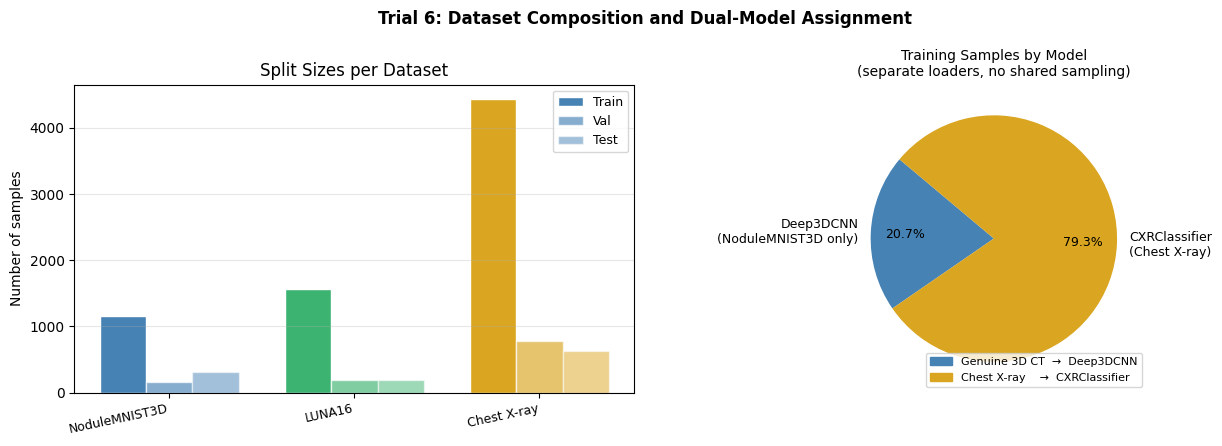

Deep3DCNN : train=1,158  val=165  test=505
CXRClassifier: train=4,433  val=783  test=624
CXR class balance: Cancer=3293 (74.3%)  NORMAL=1140 (25.7%)


In [8]:
# Dataset composition overview — visualize split sizes and model assignment.

import matplotlib.patches as mpatches

datasets_info = {
    "NoduleMNIST3D":  {"train": len(train_ds),    "val": len(val_ds),    "test": len(test_ds),    "key": "nodule"},
    "LUNA16":         {"train": len(luna16_train), "val": len(luna16_val),"test": len(luna16_test),"key": "luna16"},
    "Chest X-ray":    {"train": len(cxr_train),    "val": len(cxr_val),  "test": len(cxr_test),   "key": "cxr"},
}
COLORS = {"nodule": "steelblue", "luna16": "mediumseagreen", "cxr": "goldenrod"}

ds_names = list(datasets_info.keys())
x = np.arange(len(ds_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Trial 6: Dataset Composition and Dual-Model Assignment", fontsize=12, fontweight="bold")

for split, offset, alpha in [("train", -width, 1.0), ("val", 0, 0.65), ("test", width, 0.5)]:
    vals   = [datasets_info[n][split] for n in ds_names]
    colors = [COLORS[datasets_info[n]["key"]] for n in ds_names]
    axes[0].bar(x + offset, vals, width, label=split.capitalize(), color=colors, alpha=alpha, edgecolor="white")
axes[0].set_xticks(x); axes[0].set_xticklabels(ds_names, rotation=12, ha="right", fontsize=9)
axes[0].set_ylabel("Number of samples"); axes[0].set_title("Split Sizes per Dataset")
axes[0].legend(fontsize=9); axes[0].grid(axis="y", alpha=0.3)

model_sizes = {
    "Deep3DCNN\n(NoduleMNIST3D only)": len(deep_train_ds),
    "CXRClassifier\n(Chest X-ray)":          len(cxr_train),
}
axes[1].pie(model_sizes.values(), labels=model_sizes.keys(),
            colors=["steelblue", "goldenrod"], autopct="%1.1f%%",
            startangle=140, textprops={"fontsize": 9}, pctdistance=0.72)
patches = [
    mpatches.Patch(color="steelblue", label="Genuine 3D CT  →  Deep3DCNN"),
    mpatches.Patch(color="goldenrod", label="Chest X-ray    →  CXRClassifier"),
]
axes[1].legend(handles=patches, loc="lower right", fontsize=8)
axes[1].set_title("Training Samples by Model\n(separate loaders, no shared sampling)", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"dataset_composition_{RUN_ID}.png"), dpi=200)
plt.show()

print(f"Deep3DCNN : train={len(deep_train_ds):,}  val={len(deep_val_ds):,}  test={len(test_ds)+len(luna16_test):,}")
print(f"CXRClassifier: train={len(cxr_train):,}  val={len(cxr_val):,}  test={len(cxr_test):,}")
print(f"CXR class balance: Cancer={n_cxr_pos} ({100*n_cxr_pos/len(cxr_train):.1f}%)  "
      f"NORMAL={n_cxr_neg} ({100*n_cxr_neg/len(cxr_train):.1f}%)")


Important note: MedMNIST labels are typically shaped (N, 1). We’ll flatten later.

## Handle class imbalance helper
### Using `pos_weight`

In [9]:
def get_label_array(ds):
    return np.array([int(np.array(ds[i][1]).reshape(-1)[0]) for i in range(len(ds))], dtype=int)

# ── Deep3DCNN pos_weight (NoduleMNIST3D only) ─────────────────────────────────
# Trial 6: NoduleMNIST3D has ~25% positives, so pos_weight ~3x compensates.
y_deep = get_label_array(deep_train_ds)
n_pos_d, n_neg_d = int((y_deep == 1).sum()), int((y_deep == 0).sum())
deep_pos_weight   = torch.tensor([n_neg_d / max(n_pos_d, 1)], dtype=torch.float32, device=device)

# ── CXRClassifier pos_weight and sampling weights ─────────────────────────────
n_pos_s = sum(1 for _, lbl in cxr_train.samples if lbl == 1)
n_neg_s = sum(1 for _, lbl in cxr_train.samples if lbl == 0)
small_pos_weight = torch.tensor([n_neg_s / max(n_pos_s, 1)], dtype=torch.float32, device=device)

print("Deep3DCNN   training: pos:", n_pos_d, "  neg:", n_neg_d,
      f"  pos_weight={deep_pos_weight.item():.3f}")
print("CXRClassifier training: pos:", n_pos_s, "  neg:", n_neg_s,
      f"  pos_weight={small_pos_weight.item():.3f}")

# ── WeightedRandomSampler for CXR ─────────────────────────────────────────────
# Trial 6: target a 65% Cancer rate per batch (between training 74% and test 62%).
# This bridges the training/test class distribution gap and improves specificity.
TARGET_CANCER_RATE = 0.65
cxr_sample_weights = torch.tensor(
    [TARGET_CANCER_RATE / n_pos_s if lbl == 1 else (1 - TARGET_CANCER_RATE) / n_neg_s
     for _, lbl in cxr_train.samples],
    dtype=torch.float,
)
print(f"CXR sampler: targeting {TARGET_CANCER_RATE*100:.0f}% Cancer per batch "
      f"(was 50/50 in Trial 5; test is 62.5%)")


Deep3DCNN   training: pos: 295   neg: 863   pos_weight=2.925
CXRClassifier training: pos: 3293   neg: 1140   pos_weight=0.346
CXR sampler: targeting 65% Cancer per batch (was 50/50 in Trial 5; test is 62.5%)


## DataLoader

In [10]:
# ── 3D augmentation collate (Deep3DCNN only) ──────────────────────────────────
# Trial 6: after normalisation, trilinear upsample to PATCH_SIZE (32³).
# NoduleMNIST3D patches are 28³; LUNA16 patches are already PATCH_SIZE.
# The Deep3DCNN GAP head handles any spatial size, so no architecture change needed.
def collate_fn(batch, train=False):
    xs, ys = zip(*batch)
    x = torch.tensor(np.stack(xs)).float()
    y = torch.tensor(np.stack(ys)).long()
    if x.ndim == 4:
        x = x.unsqueeze(1)

    eps = 1e-6
    mean = x.mean(dim=(2, 3, 4), keepdim=True)
    std  = x.std(dim=(2, 3, 4), keepdim=True)
    x    = (x - mean) / (std + eps)

    # Upsample to PATCH_SIZE if needed (NoduleMNIST3D: 28 → 32)
    if x.shape[-1] != PATCH_SIZE:
        x = F.interpolate(x, size=(PATCH_SIZE,) * 3,
                          mode="trilinear", align_corners=False)

    if train:
        for dim in [2, 3, 4]:
            if torch.rand(1).item() < 0.5:
                x = torch.flip(x, dims=[dim])
        if torch.rand(1).item() < 0.3:
            x = torch.rot90(x, k=torch.randint(1, 4, (1,)).item(), dims=[3, 4])
        if torch.rand(1).item() < 0.3:
            D = x.shape[2]
            scale = 1.0 + 0.15 * torch.rand(1).item()
            new_D = max(int(D * scale), D + 1)
            xz    = F.interpolate(x, size=(new_D,) * 3, mode="trilinear", align_corners=False)
            s     = (new_D - D) // 2
            x     = xz[:, :, s:s+D, s:s+D, s:s+D]
        if torch.rand(1).item() < 0.3:
            x = x * (0.9 + 0.2 * torch.rand(1).item())
        if torch.rand(1).item() < 0.3:
            x = x + 0.05 * torch.randn_like(x)
        # Trial 6: random cutout (zero out a random 8³ sub-cube)
        if torch.rand(1).item() < 0.2:
            D = x.shape[2]
            csize = 8
            d0 = torch.randint(0, max(1, D - csize), (1,)).item()
            h0 = torch.randint(0, max(1, D - csize), (1,)).item()
            w0 = torch.randint(0, max(1, D - csize), (1,)).item()
            x[:, :, d0:d0+csize, h0:h0+csize, w0:w0+csize] = 0.0
    return x, y

# ── 2D collate for CXRClassifier ──────────────────────────────────────────────
def cxr_collate_fn(batch):
    xs, ys = zip(*batch)
    x = torch.stack(xs)
    y = torch.tensor([int(np.array(yi).reshape(-1)[0]) for yi in ys]).long()
    return x, y

_kw = dict(num_workers=cfg.num_workers, pin_memory=False)
_col_train = lambda b: collate_fn(b, train=True)
_col_eval  = lambda b: collate_fn(b, train=False)

# ── Model 1: Deep3DCNN loaders (NoduleMNIST3D only, uniform shuffle) ──────────
# Trial 6: no WeightedRandomSampler needed since we train on one dataset only.
deep_train_loader = DataLoader(
    deep_train_ds, batch_size=cfg.batch_size,
    shuffle=True, collate_fn=_col_train, **_kw,
)
deep_val_loader   = DataLoader(deep_val_ds, batch_size=cfg.batch_size,
                               shuffle=False, collate_fn=_col_eval, **_kw)
nodule_val_loader = DataLoader(val_ds, batch_size=cfg.batch_size,
                               shuffle=False, collate_fn=_col_eval, **_kw)

# ── Model 2: CXRClassifier loaders ────────────────────────────────────────────
small_train_loader = DataLoader(
    cxr_train, batch_size=32,
    sampler=WeightedRandomSampler(cxr_sample_weights, len(cxr_train), replacement=True),
    collate_fn=cxr_collate_fn, **_kw,
)
small_val_loader = DataLoader(cxr_val, batch_size=32, shuffle=False,
                              collate_fn=cxr_collate_fn, **_kw)

# ── Test loaders ──────────────────────────────────────────────────────────────
test_loader          = DataLoader(test_ds,    batch_size=cfg.batch_size, shuffle=False, collate_fn=_col_eval, **_kw)
luna16_test_loader   = DataLoader(luna16_test, batch_size=cfg.batch_size, shuffle=False, collate_fn=_col_eval, **_kw)
cxr_test_loader      = DataLoader(cxr_test,   batch_size=32, shuffle=False, collate_fn=cxr_collate_fn, **_kw)
combined_test_loader = DataLoader(combined_test_ds, batch_size=cfg.batch_size,
                                  shuffle=False, collate_fn=_col_eval, **_kw)

print("Deep3DCNN    - train:", len(deep_train_loader),  "batches  |  val:", len(deep_val_loader))
print("CXRClassifier - train:", len(small_train_loader), "batches  |  val:", len(small_val_loader))
print("Test sets     - nodule:", len(test_loader), " luna16:", len(luna16_test_loader),
      " cxr:", len(cxr_test_loader))


Deep3DCNN    - train: 10 batches  |  val: 2
CXRClassifier - train: 139 batches  |  val: 25
Test sets     - nodule: 3  luna16: 2  cxr: 20


## Data Visualization

x0 shape: (1, 28, 28, 28)   dtype: float64   min: 0.0   max: 1.0   label: [0]


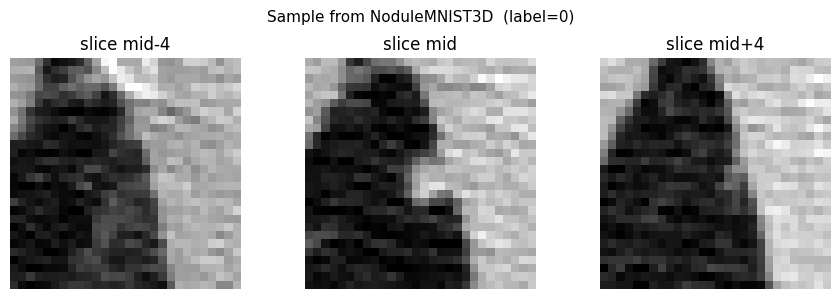

batch shapes: torch.Size([128, 1, 32, 32, 32]) torch.Size([128, 1])


In [11]:
# Inspect a single sample to confirm shapes and label format
x0, y0 = train_ds[0]
x0 = np.array(x0)
print("x0 shape:", x0.shape, "  dtype:", x0.dtype,
      "  min:", x0.min(), "  max:", x0.max(), "  label:", y0)

vol = x0[0] if x0.ndim == 4 else x0
mid = vol.shape[0] // 2

# Auto-scale each slice so we can see the content regardless of intensity range
def _auto(sl):
    lo, hi = sl.min(), sl.max()
    return (sl - lo) / (hi - lo + 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
fig.suptitle(f"Sample from NoduleMNIST3D  (label={int(np.array(y0).ravel()[0])})", fontsize=11)
axes[0].imshow(_auto(vol[mid-4]), cmap="gray"); axes[0].set_title("slice mid-4"); axes[0].axis("off")
axes[1].imshow(_auto(vol[mid]),   cmap="gray"); axes[1].set_title("slice mid");   axes[1].axis("off")
axes[2].imshow(_auto(vol[mid+4]), cmap="gray"); axes[2].set_title("slice mid+4"); axes[2].axis("off")
plt.tight_layout()
plt.show()

xb, yb = next(iter(deep_train_loader))
print("batch shapes:", xb.shape, yb.shape)


## Case Examples: Benign vs Malignant

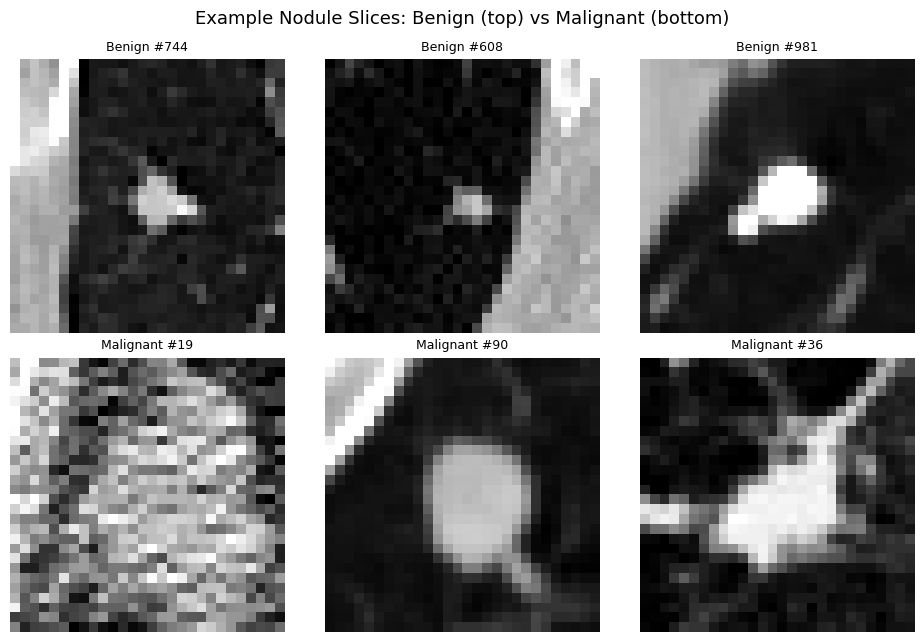

In [12]:
# Representative slices for each class

def show_class_examples(ds, n_per_class=3, seed=0):
    rng = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    benign_idx    = np.where(y_all == 0)[0]
    malignant_idx = np.where(y_all == 1)[0]

    chosen_b = rng.choice(benign_idx,    size=n_per_class, replace=False)
    chosen_m = rng.choice(malignant_idx, size=n_per_class, replace=False)

    fig, axes = plt.subplots(
        2, n_per_class, figsize=(n_per_class * 3.2, 6.5)
    )
    fig.suptitle("Example Nodule Slices: Benign (top) vs Malignant (bottom)", fontsize=13)

    for col, idx in enumerate(chosen_b):
        vol = np.array(ds[idx][0])            # (1, 28, 28, 28) or (28,28,28)
        vol = vol[0] if vol.ndim == 4 else vol
        mid = vol.shape[0] // 2
        axes[0, col].imshow(vol[mid], cmap="gray")
        axes[0, col].set_title(f"Benign #{idx}", fontsize=9)
        axes[0, col].axis("off")

    for col, idx in enumerate(chosen_m):
        vol = np.array(ds[idx][0])
        vol = vol[0] if vol.ndim == 4 else vol
        mid = vol.shape[0] // 2
        axes[1, col].imshow(vol[mid], cmap="gray")
        axes[1, col].set_title(f"Malignant #{idx}", fontsize=9)
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"case_examples_{RUN_ID}.png"), dpi=200)
    plt.show()

show_class_examples(train_ds, n_per_class=3)

## 3D Surface Visualization

Using marching cubes to render the nodule as a 3D mesh surface, adapted from Guido Zuidhof's DICOM preprocessing notebook. The threshold controls which voxel intensity is treated as the nodule boundary.

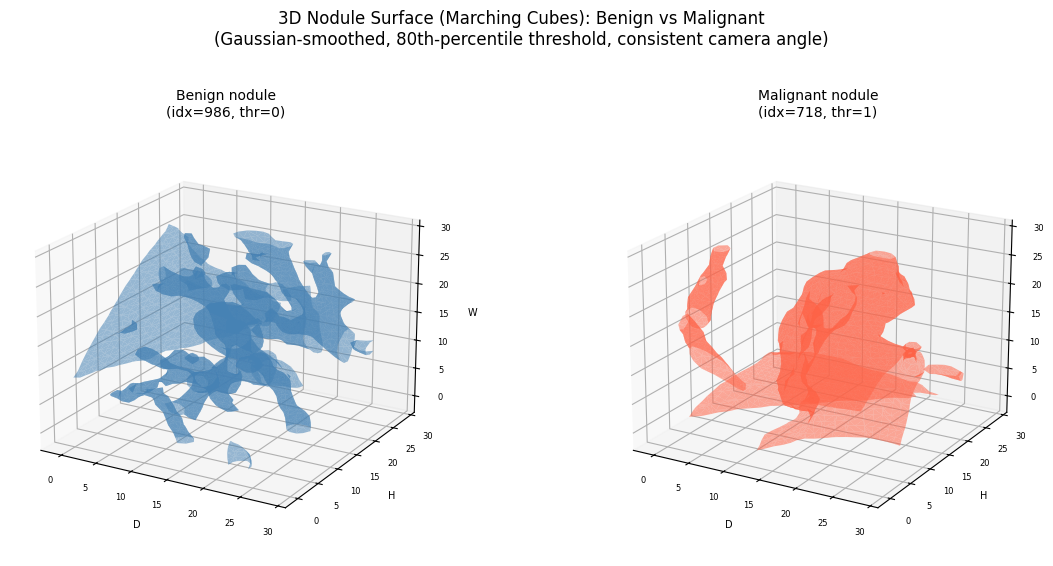

In [13]:
# 3D surface visualization using marching cubes.
# Gaussian smoothing applied before marching cubes reduces the voxel-level
# staircase noise that produces the "blob" appearance.
# A tighter percentile threshold (80th) captures only the core nodule tissue.

import scipy.ndimage as nd_img

def plot_3d_nodule(vol, threshold=None, color="steelblue", title="", ax=None):
    """
    Render a 28×28×28 nodule volume as a 3D isosurface (marching cubes).

    vol       : (1,D,H,W) or (D,H,W) uint8/float array
    threshold : HU/intensity level.  None → 80th percentile of the smoothed vol.
    """
    if vol.ndim == 4:
        vol = vol[0]
    vol_f = vol.astype(np.float32)

    # Gaussian smooth to suppress voxel-level noise before surface extraction
    vol_s = nd_img.gaussian_filter(vol_f, sigma=0.8)

    if threshold is None:
        threshold = float(np.percentile(vol_s, 80))

    try:
        verts, faces, _, _ = measure.marching_cubes(vol_s, level=threshold)
    except (ValueError, RuntimeError):
        print(f"  No surface at thr={threshold:.1f} for \"{title}\"")
        return

    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(5, 5))
        ax  = fig.add_subplot(111, projection='3d')

    mesh = Poly3DCollection(verts[faces], alpha=0.55, linewidth=0)
    mesh.set_facecolor(color)
    mesh.set_edgecolor("none")
    ax.add_collection3d(mesh)

    D, H, W = vol_f.shape
    # Add generous padding so the surface sits inside the axes
    PAD = 3
    ax.set_xlim(-PAD, D + PAD)
    ax.set_ylim(-PAD, H + PAD)
    ax.set_zlim(-PAD, W + PAD)

    ax.set_title(title or f"3D surface (thr={threshold:.0f})", fontsize=10, pad=6)
    ax.set_xlabel("D", fontsize=7); ax.set_ylabel("H", fontsize=7); ax.set_zlabel("W", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=20, azim=-60)   # consistent camera angle

    if standalone:
        plt.tight_layout()
        plt.show()


def show_3d_class_examples(ds, seed=0):
    """Side-by-side 3D surface renders for one benign and one malignant nodule."""
    rng   = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    idx_b = int(rng.choice(np.where(y_all == 0)[0]))
    idx_m = int(rng.choice(np.where(y_all == 1)[0]))

    fig = plt.figure(figsize=(12, 5.5))
    fig.suptitle(
        "3D Nodule Surface (Marching Cubes): Benign vs Malignant\n"
        "(Gaussian-smoothed, 80th-percentile threshold, consistent camera angle)",
        fontsize=12, y=1.02
    )

    for col, (label_name, idx, color) in enumerate(
        [("Benign", idx_b, "steelblue"), ("Malignant", idx_m, "tomato")]
    ):
        ax  = fig.add_subplot(1, 2, col + 1, projection='3d')
        vol = np.array(ds[idx][0])
        thr = float(np.percentile(nd_img.gaussian_filter(
            vol.squeeze().astype(np.float32), sigma=0.8), 80))
        plot_3d_nodule(vol, threshold=thr, color=color,
                       title=f"{label_name} nodule\n(idx={idx}, thr={thr:.0f})", ax=ax)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"3d_surface_{RUN_ID}.png"), dpi=200, bbox_inches="tight")
    plt.show()


show_3d_class_examples(train_ds)


## Full 3D Lung CT Reconstruction

Renders a complete LUNA16 CT scan as a 3D isosurface mesh using marching cubes.
Two thresholds are shown:
- **−300 HU** (navy): captures lung walls, soft tissue, vessels, and bone, similar to the standard 3D reconstructions used in radiological workstations
- **+200 HU** (sienna): captures dense structures only (bone and calcified tissue)

The scan is downsampled before rendering to keep memory usage reasonable. Annotated nodule positions are overlaid as scatter points.

Rendering : 1.3.6.1.4.1.14519.5.2.1.6279.6001.10062138301623374678017074...
Nodules   : 4
Scan shape : (321, 512, 512)  (Z×Y×X)
HU range   : -1000 – 3000
Spacing    : 0.56×0.56×1.00 mm/vox
Downsampled: (112, 179, 179)


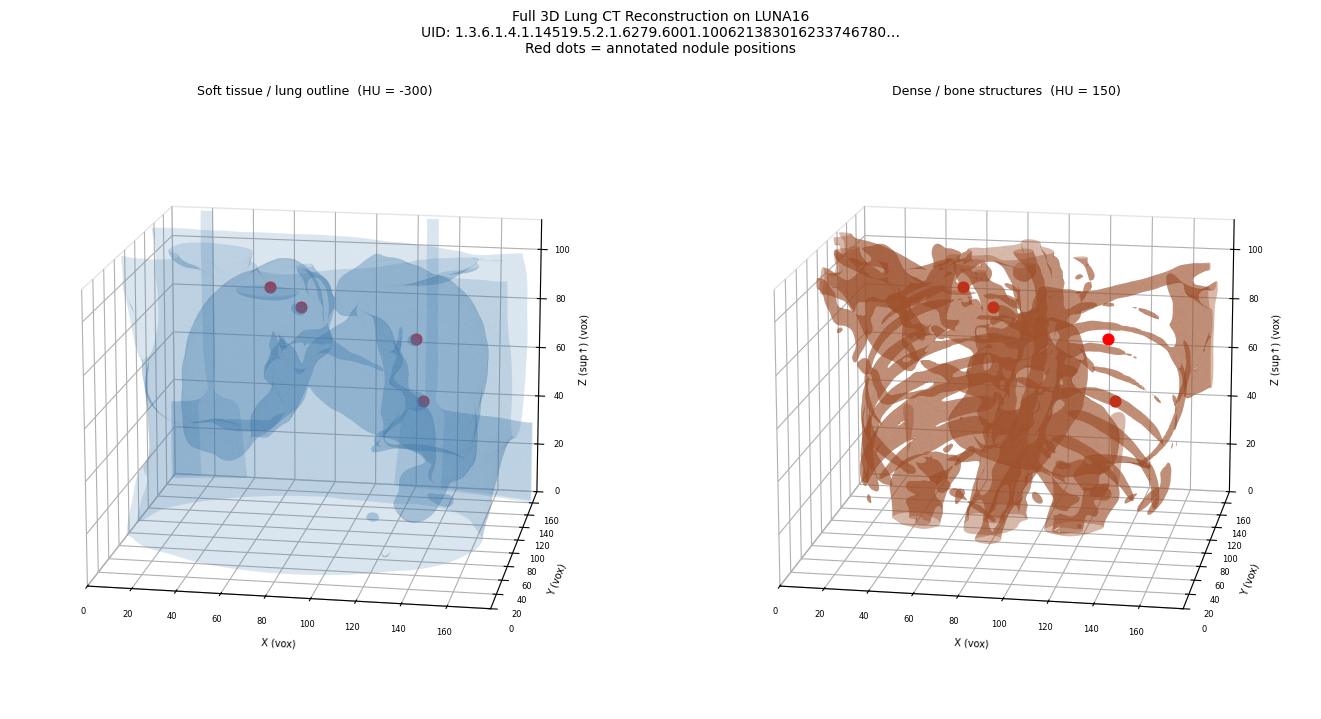

In [14]:
import SimpleITK as sitk
import scipy.ndimage as nd_img
import pandas as pd
from pathlib import Path

LUNA16_ROOT = Path(os.path.join(REPO_ROOT, "data", "Luna16"))
ann_df = pd.read_csv(LUNA16_ROOT / "annotations.csv")

def render_full_lung(mhd_path: str, nodule_coords=None, downsample_factor=0.35,
                     threshold_soft=-300.0, threshold_bone=150.0):
    """
    Load a full LUNA16 CT scan and render it as two 3D isosurface meshes.

    - threshold_soft (-300 HU): captures lung walls, airways, vessels, and soft tissue
    - threshold_bone (+200 HU): captures dense/bone structures (ribs, spine)
    Nodule world-coordinate annotations are overlaid as red scatter points.
    """
    img    = sitk.ReadImage(mhd_path)
    hu_arr = sitk.GetArrayFromImage(img).astype(np.float32)  # (Z, Y, X) in HU
    origin  = np.array(img.GetOrigin())    # (X, Y, Z) mm
    spacing = np.array(img.GetSpacing())   # (X, Y, Z) mm/voxel

    print(f"Scan shape : {hu_arr.shape}  (Z×Y×X)")
    print(f"HU range   : {hu_arr.min():.0f} – {hu_arr.max():.0f}")
    print(f"Spacing    : {spacing[0]:.2f}×{spacing[1]:.2f}×{spacing[2]:.2f} mm/vox")

    # Downsample for rendering speed
    arr_ds = nd_img.zoom(hu_arr, [downsample_factor]*3, order=1)
    print(f"Downsampled: {arr_ds.shape}")

    # Correct orientation
    # SimpleITK loads LUNA16 as (Z, Y, X) where Z goes from inferior to superior.
    # Transposing to (X, Y, Z) puts the patient upright in the matplotlib 3D axes
    # (z-axis = superior direction = "up").
    arr_plot = arr_ds.transpose(2, 1, 0)   # now (X, Y, Z)
    Nx, Ny, Nz = arr_plot.shape

    def mc(arr, level):
        try:
            v, f, _, _ = measure.marching_cubes(arr, level=level)
            return v, f
        except (ValueError, RuntimeError):
            return None, None

    # Gaussian smoothing before marching cubes removes voxel-level
    # staircasing noise that makes the surface look rough/spiky.
    arr_smooth = nd_img.gaussian_filter(arr_plot, sigma=2.0)
    verts_s, faces_s = mc(arr_smooth, threshold_soft)
    verts_b, faces_b = mc(arr_smooth, threshold_bone)

    # Convert nodule world-coords → downsampled plot voxel coords
    nodule_plot_coords = []
    if nodule_coords:
        for cx_mm, cy_mm, cz_mm in nodule_coords:
            xi = ((cx_mm - origin[0]) / spacing[0]) * downsample_factor
            yi = ((cy_mm - origin[1]) / spacing[1]) * downsample_factor
            zi = ((cz_mm - origin[2]) / spacing[2]) * downsample_factor
            # After transpose(2,1,0): new axes are xi→x, yi→y, zi→z
            nodule_plot_coords.append((xi, yi, zi))

    # Render
    fig = plt.figure(figsize=(14, 7))   # light / white background
    fig.patch.set_facecolor("white")

    panel_configs = [
        (verts_s, faces_s, "steelblue", 0.20,
         f"Soft tissue / lung outline  (HU = {threshold_soft:.0f})"),
        (verts_b, faces_b, "sienna",    0.45,
         f"Dense / bone structures  (HU = {threshold_bone:.0f})"),
    ]

    for col, (verts, faces, color, alpha, label) in enumerate(panel_configs):
        ax = fig.add_subplot(1, 2, col + 1, projection="3d")
        ax.set_facecolor("white")

        if verts is not None:
            mesh = Poly3DCollection(verts[faces], alpha=alpha, linewidth=0)
            mesh.set_facecolor(color)
            mesh.set_edgecolor("none")
            ax.add_collection3d(mesh)

        ax.set_xlim(0, Nx); ax.set_ylim(0, Ny); ax.set_zlim(0, Nz)
        ax.view_init(elev=15, azim=-80)      # patient upright, slightly front-facing

        # Overlay nodule positions
        for xi, yi, zi in nodule_plot_coords:
            ax.scatter([xi], [yi], [zi], c="red", s=60, zorder=10,
                       depthshade=False, label="annotated nodule")

        ax.set_title(label, fontsize=9, color="black", pad=4)
        ax.set_xlabel("X (vox)", fontsize=7)
        ax.set_ylabel("Y (vox)", fontsize=7)
        ax.set_zlabel("Z (sup↑) (vox)", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor("#cccccc")
        ax.yaxis.pane.set_edgecolor("#cccccc")
        ax.zaxis.pane.set_edgecolor("#cccccc")
        ax.grid(True, alpha=0.2)

    uid = Path(mhd_path).stem
    plt.suptitle(
        f"Full 3D Lung CT Reconstruction on LUNA16\nUID: {uid[:55]}…\n"
        f"Red dots = annotated nodule positions",
        fontsize=10, color="black", y=1.02
    )
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"full_lung_3d_{RUN_ID}.png"),
                dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()


# Pick a scan with ≥2 annotated nodules
uid_to_mhd = {p.stem: str(p)
               for p in sorted(LUNA16_ROOT.glob("subset*/subset*/*.mhd"))}

ann_filt = ann_df[ann_df.seriesuid.isin(uid_to_mhd)]
counts   = ann_filt.groupby("seriesuid").size()
chosen_uid = counts[counts >= 2].index[0]
chosen_mhd = uid_to_mhd[chosen_uid]

nodule_xyz = list(ann_filt[ann_filt.seriesuid == chosen_uid]
                  [["coordX","coordY","coordZ"]].itertuples(index=False, name=None))

print(f"Rendering : {chosen_uid[:60]}...")
print(f"Nodules   : {len(nodule_xyz)}")
render_full_lung(chosen_mhd, nodule_coords=nodule_xyz)


## Multi-View Slice Comparison (Axial / Sagittal / Coronal)

Displays the three orthogonal mid-plane cuts, the same views radiologists use when reading a CT scan.

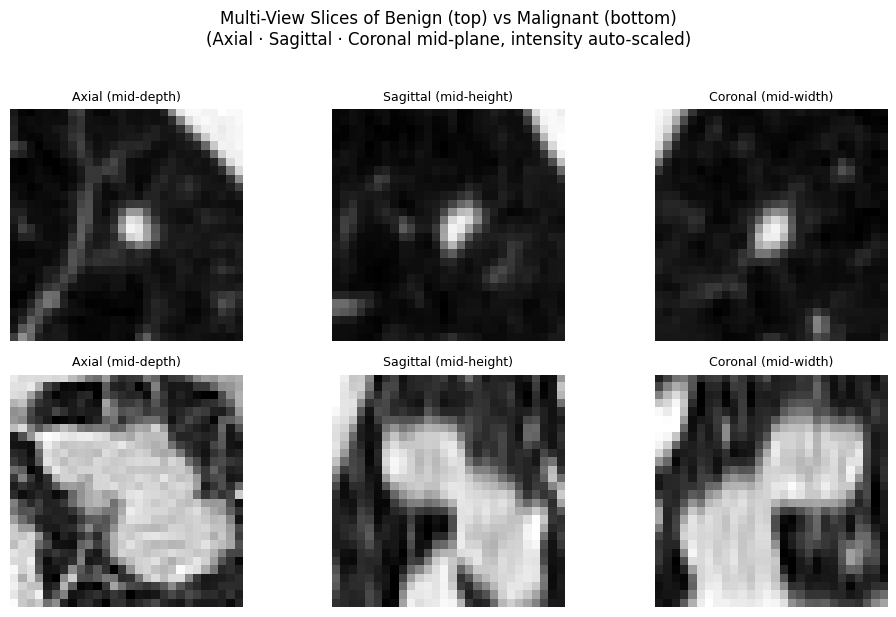

In [15]:
# Multi-view visualization: axial, sagittal, and coronal mid-plane slices
# Mirrors the standard radiology reading planes used in clinical CT review.

def show_multiview(vol, title="", cmap="gray", ax_row=None):
    """
    Display axial (D), sagittal (H), and coronal (W) mid-plane slices.
    vol: (1, D, H, W) or (D, H, W) uint8/float array.
    Auto-scales intensity so the image is never black regardless of data range.
    """
    if vol.ndim == 4:
        vol = vol[0]
    d, h, w = vol.shape

    vol_f = vol.astype(np.float32)
    # Clip to [1st, 99th] percentile and rescale to [0, 1] — prevents
    # all-black images when the raw intensity range is very small.
    lo, hi = np.percentile(vol_f, 1), np.percentile(vol_f, 99)
    if hi > lo:
        vol_f = np.clip(vol_f, lo, hi)
        vol_f = (vol_f - lo) / (hi - lo)
    else:
        vol_f = np.zeros_like(vol_f)

    slices = [
        vol_f[d // 2, :, :],
        vol_f[:, h // 2, :],
        vol_f[:, :, w // 2],
    ]
    slice_labels = ["Axial (mid-depth)", "Sagittal (mid-height)", "Coronal (mid-width)"]

    if ax_row is None:
        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        standalone = True
    else:
        axes = ax_row
        standalone = False

    for ax, sl, st in zip(axes, slices, slice_labels):
        ax.imshow(sl, cmap=cmap, vmin=0, vmax=1)
        ax.set_title(st, fontsize=9)
        ax.axis("off")

    if standalone:
        fig.suptitle(title, fontsize=11)
        plt.tight_layout()
        plt.show()


def show_multiview_class_comparison(ds, seed=0):
    """Show axial/sagittal/coronal views for one benign and one malignant sample."""
    rng = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    idx_b = int(rng.choice(np.where(y_all == 0)[0]))
    idx_m = int(rng.choice(np.where(y_all == 1)[0]))

    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    fig.suptitle(
        "Multi-View Slices of Benign (top) vs Malignant (bottom)\n"
        "(Axial · Sagittal · Coronal mid-plane, intensity auto-scaled)",
        fontsize=12, y=1.02
    )

    show_multiview(np.array(ds[idx_b][0]), ax_row=axes[0])
    show_multiview(np.array(ds[idx_m][0]), ax_row=axes[1])

    axes[0][0].set_ylabel("Benign", fontsize=10, labelpad=8)
    axes[1][0].set_ylabel("Malignant", fontsize=10, labelpad=8)

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"multiview_comparison_{RUN_ID}.png"), dpi=200)
    plt.show()


show_multiview_class_comparison(train_ds)


## Model 1: Deep3DCNN Genuine 3D Datasets

**Training data:** NoduleMNIST3D + LUNA16 (both are genuine 28³ voxel patches with real 3D spatial structure).

**Architecture:** Deep3DCNN (~3.5 M params), 4 residual stages with doubled channel widths, 3 MaxPool layers collapsing 28→14→7→3 voxels, dropout=0.5.

**Loss:** Label-smoothed BCE (ε=0.05) to reduce overconfidence.

**Threshold:** Tuned on NoduleMNIST3D val set → used for NoduleMNIST3D and LUNA16 test.

In [16]:
deep_model = Deep3DCNN(dropout_p=0.5).to(device)

def smooth_bce(logits, y, pos_weight, eps=LABEL_SMOOTHING):
    y_s = y.float() * (1 - eps) + eps / 2
    return F.binary_cross_entropy_with_logits(logits, y_s,
                                               pos_weight=pos_weight,
                                               reduction="mean")

deep_criterion = lambda logits, y: smooth_bce(logits, y, deep_pos_weight)

deep_optimizer = torch.optim.AdamW(deep_model.parameters(),
                                   lr=cfg.lr, weight_decay=cfg.weight_decay)
deep_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    deep_optimizer, T_max=cfg.epochs, eta_min=1e-6)

n_deep = sum(p.numel() for p in deep_model.parameters())
print(f"Deep3DCNN  : {n_deep:,} params  (~{n_deep/1e6:.2f} M)")
print(f"Loss       : label-smoothed BCE  (ε={LABEL_SMOOTHING})")
print(f"Optimizer  : AdamW  lr={cfg.lr}  wd={cfg.weight_decay}")


Deep3DCNN  : 7,070,497 params  (~7.07 M)
Loss       : label-smoothed BCE  (ε=0.05)
Optimizer  : AdamW  lr=0.0003  wd=0.0001


## Training loop

In [17]:
print("=" * 60)
print("Training Model 1: Deep3DCNN  (NoduleMNIST3D only)")
print("=" * 60)

deep_history = {"train_loss": [], "val_loss": [], "val": []}
deep_best_score  = -1.0
deep_best_epoch  = -1
patience_counter = 0

for epoch in range(1, cfg.epochs + 1):
    t_loss = train_one_epoch(deep_model, deep_train_loader,
                              deep_optimizer, deep_criterion, device)
    v_loss = evaluate_loss(deep_model, deep_val_loader, deep_criterion, device)
    v_met  = evaluate(deep_model, deep_val_loader, device,
                      threshold=cfg.threshold, criterion=deep_criterion)
    v_met["val_loss"] = v_loss
    deep_scheduler.step()

    auroc = f"{v_met['auroc']:.4f}" if v_met["auroc"] else "N/A"
    print(f"epoch {epoch:02d}/{cfg.epochs} | train {t_loss:.4f} | val {v_loss:.4f} | "
          f"auroc {auroc} | f1 {v_met['f1']:.4f} | "
          f"lr {deep_optimizer.param_groups[0]['lr']:.2e}")

    deep_history["train_loss"].append(t_loss)
    deep_history["val_loss"].append(v_loss)
    deep_history["val"].append(v_met)

    score = v_met["auroc"] if v_met["auroc"] else v_met["f1"]
    if score > deep_best_score:
        deep_best_score = score; deep_best_epoch = epoch; patience_counter = 0
        save_checkpoint(os.path.join(RUN_DIR, "best_deep.pt"),
                        deep_model, deep_optimizer, epoch,
                        {"val_metrics": v_met, "config": cfg.__dict__})
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

save_json(metrics_path, {"deep_history": deep_history, "deep_best_epoch": deep_best_epoch})
print(f"\nDeep3DCNN done.  Best epoch: {deep_best_epoch}  Val AUROC: {deep_best_score:.4f}")


Training Model 1: Deep3DCNN  (NoduleMNIST3D only)


epoch 01/50 | train 0.9992 | val 2.1522 | auroc 0.7338 | f1 0.0000 | lr 3.00e-04


epoch 02/50 | train 0.8939 | val 1.0320 | auroc 0.7909 | f1 0.5843 | lr 2.99e-04


epoch 03/50 | train 0.7775 | val 1.1447 | auroc 0.8196 | f1 0.6197 | lr 2.97e-04


epoch 04/50 | train 0.7652 | val 0.7382 | auroc 0.8405 | f1 0.6337 | lr 2.95e-04


...

epoch 28/50 | train 0.7012 | val 0.7325 | auroc 0.8513 | f1 0.7045 | lr 1.22e-04


epoch 29/50 | train 0.6531 | val 0.7348 | auroc 0.8568 | f1 0.6596 | lr 1.13e-04


epoch 30/50 | train 0.6937 | val 0.7454 | auroc 0.8620 | f1 0.6154 | lr 1.04e-04


epoch 31/50 | train 0.7065 | val 0.8021 | auroc 0.8314 | f1 0.7033 | lr 9.55e-05


epoch 32/50 | train 0.7421 | val 0.7939 | auroc 0.8419 | f1 0.6905 | lr 8.68e-05
Early stopping at epoch 32

Deep3DCNN done.  Best epoch: 22  Val AUROC: 0.8844


## Intermediate Feature Map Visualization

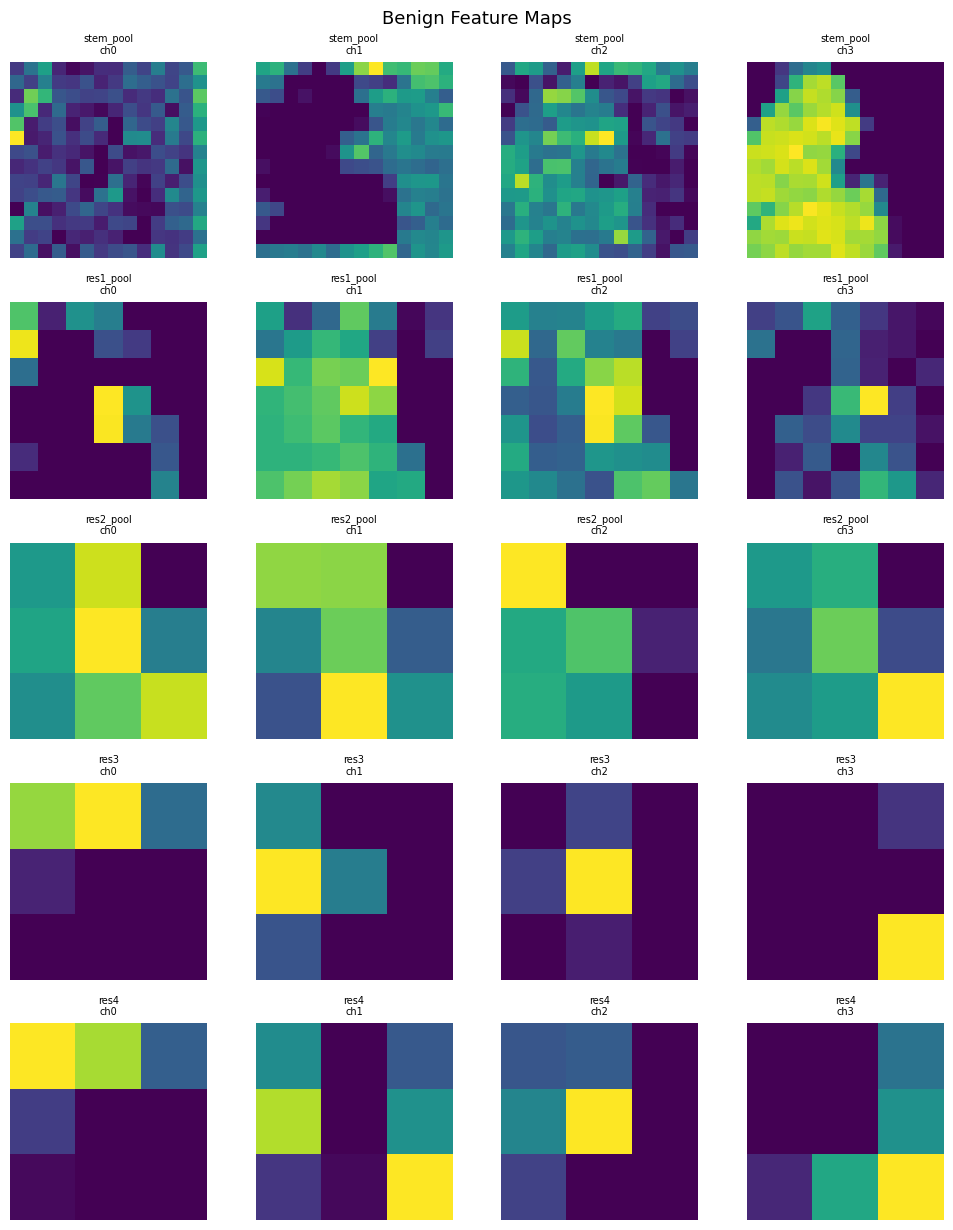

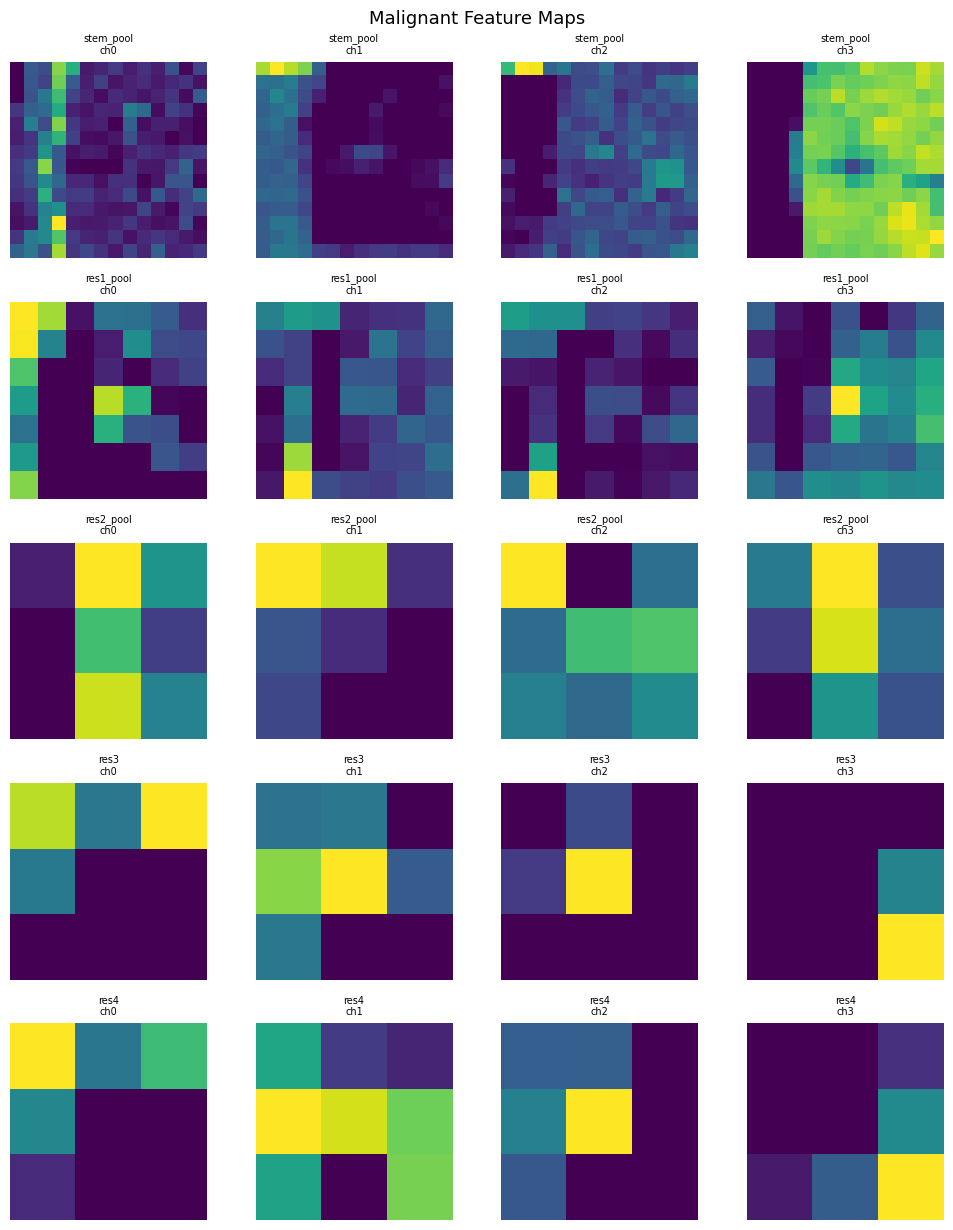

In [18]:
# Pick one benign and one malignant sample, run a forward pass,
# and display the first few channels of each residual stage.

def visualize_feature_maps(model, ds, device, n_channels=4):
    model.eval()
    y_all = get_label_array(ds)

    # pick first benign and first malignant
    idx_b = int(np.where(y_all == 0)[0][0])
    idx_m = int(np.where(y_all == 1)[0][0])

    for label_name, idx in [("Benign", idx_b), ("Malignant", idx_m)]:
        x_raw = np.array(ds[idx][0]).astype(np.float32)
        x_t   = torch.tensor(x_raw).unsqueeze(0)         # (1, 1, 28, 28, 28)
        if x_t.ndim == 4:
            x_t = x_t.unsqueeze(0)

        # Normalise the same way as collate_fn
        eps = 1e-6
        x_t = (x_t - x_t.mean()) / (x_t.std() + eps)
        x_t = x_t.to(device)

        with torch.no_grad():
            maps = model.get_feature_maps(x_t)

        stage_names = list(maps.keys())
        fig, axes = plt.subplots(
            len(stage_names), n_channels,
            figsize=(n_channels * 2.5, len(stage_names) * 2.5)
        )
        fig.suptitle(f"{label_name} Feature Maps", fontsize=13)

        for row, sname in enumerate(stage_names):
            fmap = maps[sname][0]        # (C, D, H, W) – drop batch dim
            mid_d = fmap.shape[1] // 2  # middle depth slice
            for col in range(n_channels):
                ax = axes[row, col] if len(stage_names) > 1 else axes[col]
                ch_map = fmap[col, mid_d].numpy()
                ax.imshow(ch_map, cmap="viridis")
                ax.set_title(f"{sname}\nch{col}", fontsize=7)
                ax.axis("off")

        plt.tight_layout()
        plt.savefig(
            os.path.join(FIG_DIR, f"feature_maps_{label_name.lower()}_{RUN_ID}.png"),
            dpi=200
        )
        plt.show()

visualize_feature_maps(deep_model, train_ds, device, n_channels=4)

## Threshold Tuning

**Trial 5 key change:** threshold tuned separately on the NoduleMNIST3D validation set (for the main benchmark) and on the combined validation set (for combined test evaluation).

In Trial 4, using only the combined val set pushed the threshold to 0.85, which is too conservative for NoduleMNIST3D. Separate tuning decouples the two operating points.

In [19]:
# Threshold tuning for Model 1 (Deep3DCNN)
# Tuned on NoduleMNIST3D val only so the operating point transfers to
# the NoduleMNIST3D test set (the primary cross-trial benchmark).

@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    model.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)
        all_logits.append(model(x).cpu().numpy())
        all_y.append(y.numpy().reshape(-1))
    return np.concatenate(all_y).astype(int), np.concatenate(all_logits)

y_val_nodule, logits_val_nodule = get_logits_and_labels(deep_model, nodule_val_loader, device)

thresholds = np.linspace(0.05, 0.95, 19)
best_deep_nodule = None
sweep_rows_nodule = []

for t in thresholds:
    met = compute_binary_metrics(y_val_nodule, logits_val_nodule, threshold=float(t))
    row = {"threshold": float(t), **{k: met[k] for k in
           ["f1","recall","precision","specificity","accuracy","auroc"]}}
    sweep_rows_nodule.append(row)
    if best_deep_nodule is None or row["f1"] > best_deep_nodule["f1"]:
        best_deep_nodule = row

deep_threshold = best_deep_nodule["threshold"]
print(f"Deep3DCNN NoduleMNIST3D val → best thr: {deep_threshold:.2f}  "
      f"(F1={best_deep_nodule['f1']:.3f}, "
      f"Recall={best_deep_nodule['recall']:.3f}, "
      f"Precision={best_deep_nodule['precision']:.3f})")


Deep3DCNN NoduleMNIST3D val → best thr: 0.45  (F1=0.727, Recall=0.762, Precision=0.696)


## Threshold Analysis & ROC Curve

Visualizes how each metric responds to threshold changes and the full ROC curve for the NoduleMNIST3D validation set.

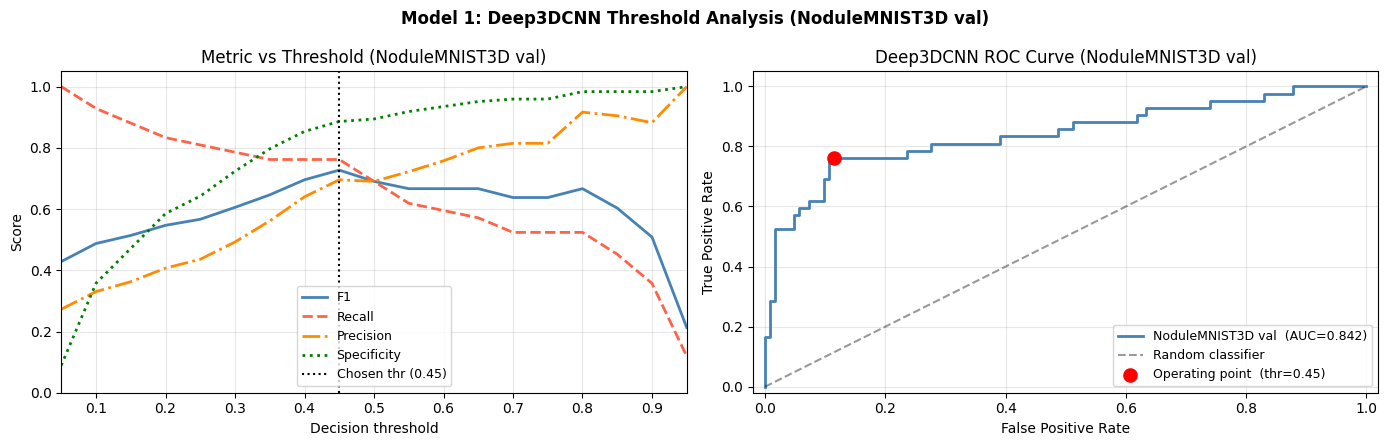

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Model 1: Deep3DCNN Threshold Analysis (NoduleMNIST3D val)",
             fontsize=12, fontweight="bold")

thr_vals = [r["threshold"] for r in sweep_rows_nodule]
for metric, color, ls in [
    ("f1",          "steelblue",  "-"),
    ("recall",      "tomato",     "--"),
    ("precision",   "darkorange", "-."),
    ("specificity", "green",      ":"),
]:
    axes[0].plot(thr_vals, [r[metric] for r in sweep_rows_nodule],
                 label=metric.capitalize(), color=color, linestyle=ls, linewidth=2)

axes[0].axvline(deep_threshold, color="black", linestyle=":", linewidth=1.5,
                label=f"Chosen thr ({deep_threshold:.2f})")
axes[0].set_xlabel("Decision threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("Metric vs Threshold (NoduleMNIST3D val)")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].set_xlim(0.05, 0.95); axes[0].set_ylim(0, 1.05)

# ROC curve
probs_nodule = sigmoid(logits_val_nodule)
fpr, tpr, _ = sk_roc_curve(y_val_nodule, probs_nodule)
roc_auc = float(np.trapezoid(tpr, fpr))

axes[1].plot(fpr, tpr, color="steelblue", linewidth=2,
             label=f"NoduleMNIST3D val  (AUC={roc_auc:.3f})")
axes[1].plot([0,1],[0,1], "k--", alpha=0.4, label="Random classifier")

probs_at_thr = (probs_nodule >= deep_threshold)
tpr_op = (probs_at_thr[y_val_nodule == 1]).mean()
fpr_op = (probs_at_thr[y_val_nodule == 0]).mean()
axes[1].scatter([fpr_op], [tpr_op], s=90, color="red", zorder=5,
                label=f"Operating point  (thr={deep_threshold:.2f})")

axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Deep3DCNN ROC Curve (NoduleMNIST3D val)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"deep_threshold_roc_{RUN_ID}.png"), dpi=200)
plt.show()


## Training Curves

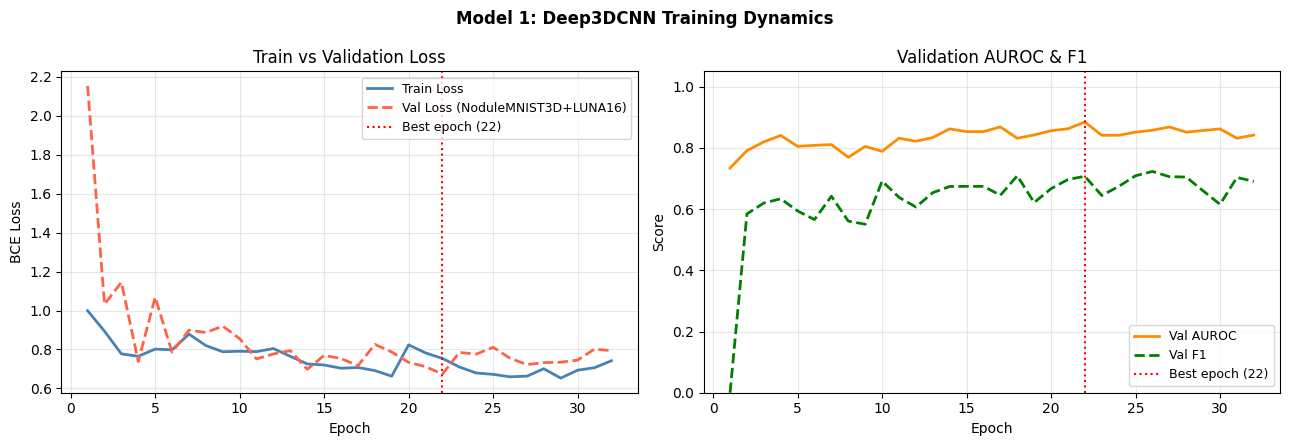

In [21]:
train_losses = deep_history["train_loss"]
val_losses   = deep_history["val_loss"]
val_aurocs   = [v["auroc"] for v in deep_history["val"]]
val_f1s      = [v["f1"]    for v in deep_history["val"]]
epochs_r     = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Model 1: Deep3DCNN Training Dynamics", fontsize=12, fontweight="bold")

axes[0].plot(epochs_r, train_losses, label="Train Loss", color="steelblue", linewidth=2)
axes[0].plot(epochs_r, val_losses,   label="Val Loss (NoduleMNIST3D+LUNA16)",
             color="tomato", linestyle="--", linewidth=2)
axes[0].axvline(deep_best_epoch, color="red", linestyle=":", linewidth=1.5,
                label=f"Best epoch ({deep_best_epoch})")
axes[0].set_title("Train vs Validation Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_r, val_aurocs, label="Val AUROC", color="darkorange", linewidth=2)
axes[1].plot(epochs_r, val_f1s,   label="Val F1",    color="green", linestyle="--", linewidth=2)
axes[1].axvline(deep_best_epoch, color="red", linestyle=":", linewidth=1.5,
                label=f"Best epoch ({deep_best_epoch})")
axes[1].set_title("Validation AUROC & F1"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score"); axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"deep_train_curves_{RUN_ID}.png"), dpi=200)
plt.show()


## Test Evaluation

Evaluate on each dataset's test split using the domain-appropriate threshold:
- **NoduleMNIST3D, IQ-OTH, LungcancerDataSet, LUNA16**: threshold tuned on NoduleMNIST3D val
- **Combined**: threshold tuned on combined val

NoduleMNIST3D test is the primary apples-to-apples comparison across all trials.

In [22]:
# Model 1 test evaluation on NoduleMNIST3D and LUNA16
nodule_test_deep  = evaluate(deep_model, test_loader,        device, threshold=deep_threshold)
luna16_test_deep  = evaluate(deep_model, luna16_test_loader, device, threshold=deep_threshold)

print(f"Model 1 (Deep3DCNN) test results  [thr={deep_threshold:.2f}]")
print(f"{'Dataset':20s}  {'AUROC':>6}  {'F1':>6}  {'Recall':>6}  {'Prec':>6}  {'Spec':>6}  {'Acc':>6}")
print("  " + "-" * 60)
for name, m in [("NoduleMNIST3D", nodule_test_deep), ("LUNA16", luna16_test_deep)]:
    def _f(v): return f"{v:.3f}" if v is not None else "N/A"
    print(f"  {name:20s}  {_f(m['auroc']):>6}  {_f(m['f1']):>6}  "
          f"{_f(m['recall']):>6}  {_f(m['precision']):>6}  "
          f"{_f(m['specificity']):>6}  {_f(m['accuracy']):>6}")


Model 1 (Deep3DCNN) test results  [thr=0.45]
Dataset                AUROC      F1  Recall    Prec    Spec     Acc
  ------------------------------------------------------------
  NoduleMNIST3D          0.915   0.671   0.766   0.598   0.866   0.845
  LUNA16                 0.492   0.314   0.311   0.317   0.694   0.574


---

## Model 2: CXRClassifier, ResNet-18 for Chest X-ray Cancer Screening

**Motivation:** Low-resource clinical settings (rural clinics, developing-world hospitals)
rarely have access to CT scanners. Chest X-ray (CXR) is the dominant first-line imaging
tool in these environments. A strong CXR classifier can triage patients for further
investigation without requiring expensive 3D scanning equipment.

**Why not Small3DCNN?**  The pseudo-3D stacking trick (same 2D slice repeated 28×) that
worked for the earlier CT-slice datasets is fundamentally unsuitable for CXR:
3D convolutions see identical content on every depth slice and cannot learn anything
from the depth direction. A proper 2D model with higher-resolution input is the right
architecture.

**CXRClassifier architecture (~11.2 M params):**

| Component | Detail |
|---|---|
| Backbone | ResNet-18 pretrained on ImageNet (torchvision) |
| Input adaptation | First conv: 3-ch RGB → 1-ch grayscale (weights averaged) |
| Input size | 224 × 224 (grayscale, normalised mean=0.5 std=0.5) |
| Feature dim | 512 (Global Average Pool output) |
| Head | Dropout(0.5) → Linear(512 → 1) |
| Loss | BCEWithLogitsLoss with pos_weight |

**Training data:** 4,433 CXR images carved from `train/` (85% stratified split of 5,216).
Internal val: 783 images (15%).  Test: 624 images from held-out `test/` folder.

**Class balance:** Cancer ≈ 74%, NORMAL ≈ 26%.
WeightedRandomSampler brings each class to equal frequency per batch.

**Threshold:** Tuned on the internal CXR validation set (max F1 sweep).


### Chest X-ray Data Exploration

Sample images and class distribution before model initialisation.

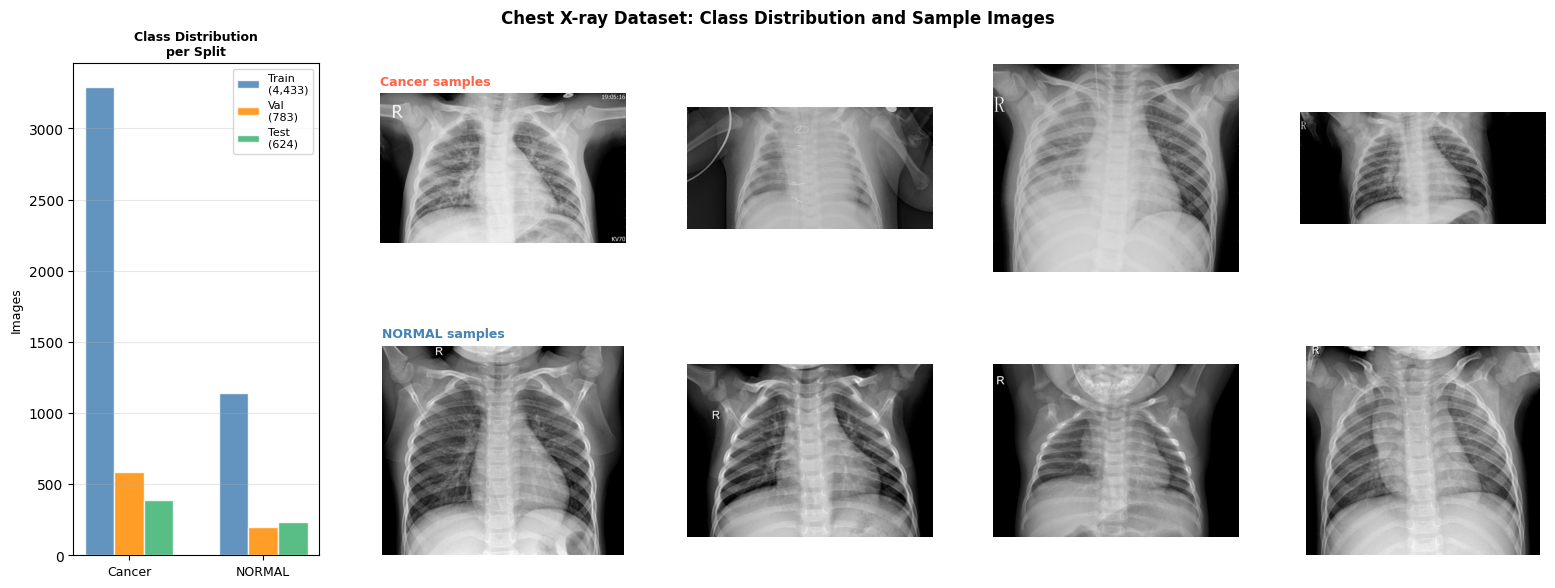

Train: Cancer=3293  NORMAL=1140  ratio=2.89:1
Val  : Cancer=582  NORMAL=201
Test : Cancer=390  NORMAL=234


In [23]:
# ── Class distribution + sample X-rays in one integrated figure ───────────────
import matplotlib.gridspec as gridspec

cxr_labels_tr = np.array([lbl for _, lbl in cxr_train.samples])
cxr_labels_va = np.array([lbl for _, lbl in cxr_val.samples])
cxr_labels_te = np.array([lbl for _, lbl in cxr_test.samples])

# Raw dataset (no transform) so we can display original pixel values
raw_ds = ChestXrayCancerDataset(cxr_train.samples, transform=None)

idx_cancer = [i for i, (_, lbl) in enumerate(raw_ds.samples) if lbl == 1][:4]
idx_normal = [i for i, (_, lbl) in enumerate(raw_ds.samples) if lbl == 0][:4]

# ── Single figure: left = bar chart (full height),
#    right = 2-row x 4-col image grid (Cancer top, NORMAL bottom) ─────────────
fig = plt.figure(figsize=(16, 6))
fig.suptitle("Chest X-ray Dataset: Class Distribution and Sample Images",
             fontsize=12, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 5, figure=fig,
                       left=0.06, right=0.98, top=0.92, bottom=0.10,
                       wspace=0.25, hspace=0.35)

# ── Left panel: grouped bar chart spanning both rows ─────────────────────────
ax_bar = fig.add_subplot(gs[:, 0])

split_data = [
    ("Train\n(4,433)", cxr_labels_tr, "steelblue"),
    ("Val\n(783)",     cxr_labels_va, "darkorange"),
    ("Test\n(624)",    cxr_labels_te, "mediumseagreen"),
]
bar_x = np.arange(2)
bar_w = 0.22
for k, (split_name, labels, color) in enumerate(split_data):
    n_cancer = (labels == 1).sum()
    n_normal = (labels == 0).sum()
    ax_bar.bar(bar_x + k * bar_w, [n_cancer, n_normal], bar_w,
               label=split_name, color=color, alpha=0.85, edgecolor="white")

ax_bar.set_xticks(bar_x + bar_w)
ax_bar.set_xticklabels(["Cancer", "NORMAL"], fontsize=9)
ax_bar.set_ylabel("Images", fontsize=9)
ax_bar.set_title("Class Distribution\nper Split", fontsize=9, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.grid(axis="y", alpha=0.3)

# ── Right panels: Cancer (row 0) + NORMAL (row 1), 4 images each ─────────────
row_cfg = [("Cancer", idx_cancer, "tomato"), ("NORMAL", idx_normal, "steelblue")]
for row, (class_name, indices, title_color) in enumerate(row_cfg):
    for col, idx in enumerate(indices):
        ax = fig.add_subplot(gs[row, col + 1])
        img, _ = raw_ds[idx]          # PIL image (no transform)
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(f"{class_name} samples", fontsize=9,
                         color=title_color, fontweight="bold", loc="left")

plt.savefig(os.path.join(FIG_DIR, f"cxr_explore_{RUN_ID}.png"), dpi=200,
            bbox_inches="tight")
plt.show()

print(f"Train: Cancer={int((cxr_labels_tr==1).sum())}  NORMAL={int((cxr_labels_tr==0).sum())}  "
      f"ratio={int((cxr_labels_tr==1).sum())/int((cxr_labels_tr==0).sum()):.2f}:1")
print(f"Val  : Cancer={int((cxr_labels_va==1).sum())}  NORMAL={int((cxr_labels_va==0).sum())}")
print(f"Test : Cancer={int((cxr_labels_te==1).sum())}  NORMAL={int((cxr_labels_te==0).sum())}")

### Model Initialisation

Pretrained ResNet-18 backbone with a 1-channel grayscale adaptation. Differential learning rates allow the backbone to fine-tune slowly while the new classification head learns faster.

In [24]:
small_model = CXRClassifier(dropout_p=0.5, pretrained=True).to(device)

# Label-smoothed loss — helps with confidence calibration on CXR data
# where labelling noise exists (folder-level, not per-nodule annotation)
def cxr_smooth_bce(logits, y, pos_weight, eps=0.05):
    y_s = y.float() * (1 - eps) + eps / 2
    return F.binary_cross_entropy_with_logits(logits, y_s,
                                               pos_weight=pos_weight,
                                               reduction="mean")

small_criterion = lambda logits, y: cxr_smooth_bce(logits, y, small_pos_weight)

# Fine-tuning strategy: lower LR for pretrained backbone, higher for new head
backbone_params = list(small_model.features.parameters())
head_params     = list(small_model.fc.parameters()) + list(small_model.drop.parameters())

small_optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 1e-4},   # pretrained — fine-tune carefully
    {"params": head_params,     "lr": 5e-4},   # new head   — learn faster
], weight_decay=1e-4)

small_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    small_optimizer, T_max=cfg.epochs, eta_min=1e-6
)

n_total  = sum(p.numel() for p in small_model.parameters())
n_head   = sum(p.numel() for p in head_params)
n_back   = sum(p.numel() for p in backbone_params)
print(f"CXRClassifier total : {n_total:,} params  (~{n_total/1e6:.2f} M)")
print(f"  Backbone (ResNet-18): {n_back:,}")
print(f"  Head (Drop+FC)      : {n_head:,}")
print(f"Loss: label-smoothed BCEWithLogitsLoss (eps=0.05)  pos_weight={small_pos_weight.item():.3f}")
print(f"Optimizer: AdamW differential LR  (backbone=1e-4, head=5e-4)")


CXRClassifier total : 11,170,753 params  (~11.17 M)
  Backbone (ResNet-18): 11,170,240
  Head (Drop+FC)      : 513
Loss: label-smoothed BCEWithLogitsLoss (eps=0.05)  pos_weight=0.346
Optimizer: AdamW differential LR  (backbone=1e-4, head=5e-4)


### CXRClassifier Training

Fine-tunes the ResNet-18 backbone with differential learning rates and WeightedRandomSampler for class balance. Early stopping on val AUROC; best weights are reloaded after training.

In [25]:
print("=" * 60)
print("Training Model 2: CXRClassifier  (Chest X-ray Cancer Screening)")
print("=" * 60)

small_history = {"train_loss": [], "val_loss": [], "val": []}
small_best_score  = -1.0
small_best_epoch  = -1
patience_counter2 = 0

for epoch in range(1, cfg.epochs + 1):
    t_loss = train_one_epoch(small_model, small_train_loader,
                              small_optimizer, small_criterion, device)
    v_loss = evaluate_loss(small_model, small_val_loader, small_criterion, device)
    v_met  = evaluate(small_model, small_val_loader, device,
                      threshold=cfg.threshold, criterion=small_criterion)
    v_met["val_loss"] = v_loss
    small_scheduler.step()

    auroc = f"{v_met['auroc']:.4f}" if v_met["auroc"] else "N/A"
    print(f"epoch {epoch:02d}/{cfg.epochs} | train {t_loss:.4f} | val {v_loss:.4f} | "
          f"auroc {auroc} | f1 {v_met['f1']:.4f} | "
          f"lr_backbone {small_optimizer.param_groups[0]['lr']:.2e}")

    small_history["train_loss"].append(t_loss)
    small_history["val_loss"].append(v_loss)
    small_history["val"].append(v_met)

    score = v_met["auroc"] if v_met["auroc"] else v_met["f1"]
    if score > small_best_score:
        small_best_score = score
        small_best_epoch = epoch
        patience_counter2 = 0
        save_checkpoint(os.path.join(RUN_DIR, "best_small.pt"),
                        small_model, small_optimizer, epoch,
                        {"val_metrics": v_met, "config": cfg.__dict__})
    else:
        patience_counter2 += 1
        if patience_counter2 >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}  (patience={EARLY_STOP_PATIENCE})")
            break

# Reload best checkpoint
ckpt = torch.load(os.path.join(RUN_DIR, "best_small.pt"), map_location=device)
small_model.load_state_dict(ckpt["model_state"])
print(f"Loaded best CXRClassifier weights from epoch {small_best_epoch}")

# Persist to metrics
with open(metrics_path, "r") as f:
    m_all = json.load(f)
m_all["small_history"]    = small_history
m_all["small_best_epoch"] = small_best_epoch
with open(metrics_path, "w") as f:
    json.dump(m_all, f, indent=2)

print(f"\nCXRClassifier done.  Best epoch: {small_best_epoch}  Val AUROC: {small_best_score:.4f}")


Training Model 2: CXRClassifier  (Chest X-ray Cancer Screening)


epoch 01/50 | train 0.1402 | val 0.1155 | auroc 0.9971 | f1 0.9700 | lr_backbone 9.99e-05


epoch 02/50 | train 0.1116 | val 0.1044 | auroc 0.9985 | f1 0.9825 | lr_backbone 9.96e-05


epoch 03/50 | train 0.1043 | val 0.1107 | auroc 0.9971 | f1 0.9736 | lr_backbone 9.91e-05


epoch 04/50 | train 0.1013 | val 0.1073 | auroc 0.9988 | f1 0.9772 | lr_backbone 9.84e-05


...

epoch 29/50 | train 0.0781 | val 0.0926 | auroc 0.9991 | f1 0.9948 | lr_backbone 3.82e-05


epoch 30/50 | train 0.0780 | val 0.0914 | auroc 0.9985 | f1 0.9940 | lr_backbone 3.52e-05


epoch 31/50 | train 0.0782 | val 0.0932 | auroc 0.9981 | f1 0.9922 | lr_backbone 3.23e-05


epoch 32/50 | train 0.0773 | val 0.0930 | auroc 0.9990 | f1 0.9905 | lr_backbone 2.94e-05


epoch 33/50 | train 0.0778 | val 0.0949 | auroc 0.9990 | f1 0.9878 | lr_backbone 2.67e-05
Early stopping at epoch 33  (patience=10)
Loaded best CXRClassifier weights from epoch 23

CXRClassifier done.  Best epoch: 23  Val AUROC: 0.9996


### CXR Temperature Scaling Calibration

Post-hoc temperature scaling corrects overconfident probability outputs without
retraining the model. A single scalar T is optimised on the validation set logits:

    p_calibrated = sigmoid(logit / T)

T > 1 softens the distribution (spreads probabilities toward 0.5), allowing the
threshold sweep to find a more interpretable operating point and improving
specificity at equivalent recall. This is particularly important here because
the CXRClassifier converged to a threshold of 0.10 in Trial 5, indicating
that even NORMAL cases were being scored near 1.0.

In [26]:
# ── Temperature scaling for CXRClassifier ─────────────────────────────────────
# Collect raw val logits from the trained model
y_val_raw, logits_val_raw = get_logits_and_labels(small_model, small_val_loader, device)

# Optimise T* via scipy bounded minimisation of BCE NLL
cxr_temperature = calibrate_temperature(logits_val_raw, y_val_raw)
logits_val_calibrated = logits_val_raw / cxr_temperature

print(f"CXR temperature T* = {cxr_temperature:.4f}")
if cxr_temperature > 1:
    print(f"  T > 1: model was overconfident — probabilities softened")
else:
    print(f"  T < 1: model was underconfident — probabilities sharpened")

# Quick sanity check: compare raw vs calibrated prob distributions
probs_raw  = sigmoid(logits_val_raw)
probs_cal  = sigmoid(logits_val_calibrated)
print(f"  Val probs (raw) : mean={probs_raw.mean():.3f}  std={probs_raw.std():.3f}")
print(f"  Val probs (cal) : mean={probs_cal.mean():.3f}  std={probs_cal.std():.3f}")


CXR temperature T* = 0.4672
  T < 1: model was underconfident — probabilities sharpened
  Val probs (raw) : mean=0.690  std=0.397
  Val probs (cal) : mean=0.737  std=0.434


### CXRClassifier Training Curves

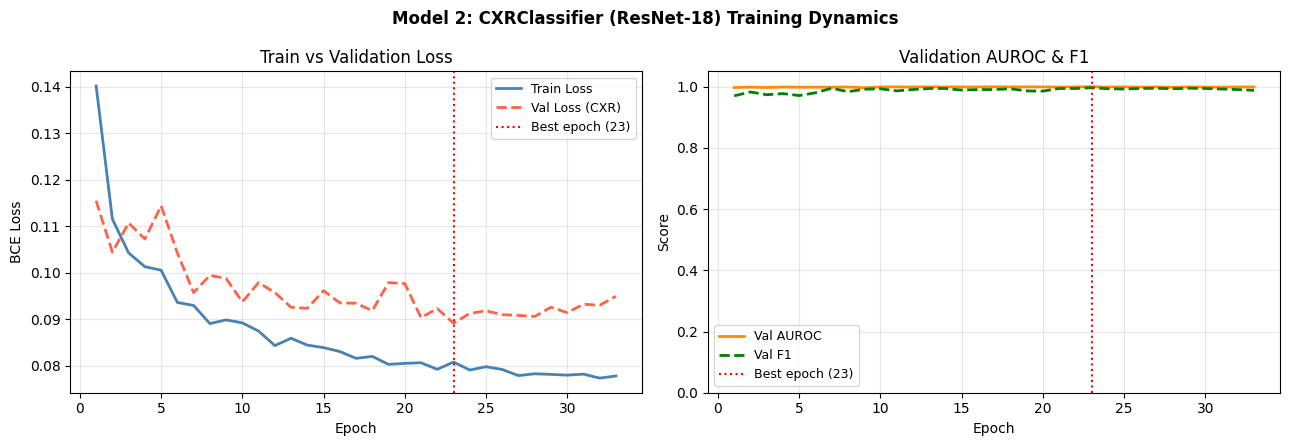

In [27]:
s_train = small_history["train_loss"]
s_val   = small_history["val_loss"]
s_auroc = [v["auroc"] for v in small_history["val"]]
s_f1    = [v["f1"]    for v in small_history["val"]]
s_ep    = range(1, len(s_train) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Model 2: CXRClassifier (ResNet-18) Training Dynamics", fontsize=12, fontweight="bold")

axes[0].plot(s_ep, s_train, label="Train Loss",    color="steelblue", linewidth=2)
axes[0].plot(s_ep, s_val,   label="Val Loss (CXR)", color="tomato", linestyle="--", linewidth=2)
axes[0].axvline(small_best_epoch, color="red", linestyle=":", linewidth=1.5,
                label=f"Best epoch ({small_best_epoch})")
axes[0].set_title("Train vs Validation Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(s_ep, s_auroc, label="Val AUROC", color="darkorange", linewidth=2)
axes[1].plot(s_ep, s_f1,    label="Val F1",    color="green", linestyle="--", linewidth=2)
axes[1].axvline(small_best_epoch, color="red", linestyle=":", linewidth=1.5,
                label=f"Best epoch ({small_best_epoch})")
axes[1].set_title("Validation AUROC & F1"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score"); axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"cxr_train_curves_{RUN_ID}.png"), dpi=200)
plt.show()


### CXRClassifier Threshold Tuning & ROC (Internal CXR Val)

CXRClassifier CXR val (calibrated) → best thr: 0.40  (F1=0.997  Recall=0.995  Precision=0.998  Spec=0.995)


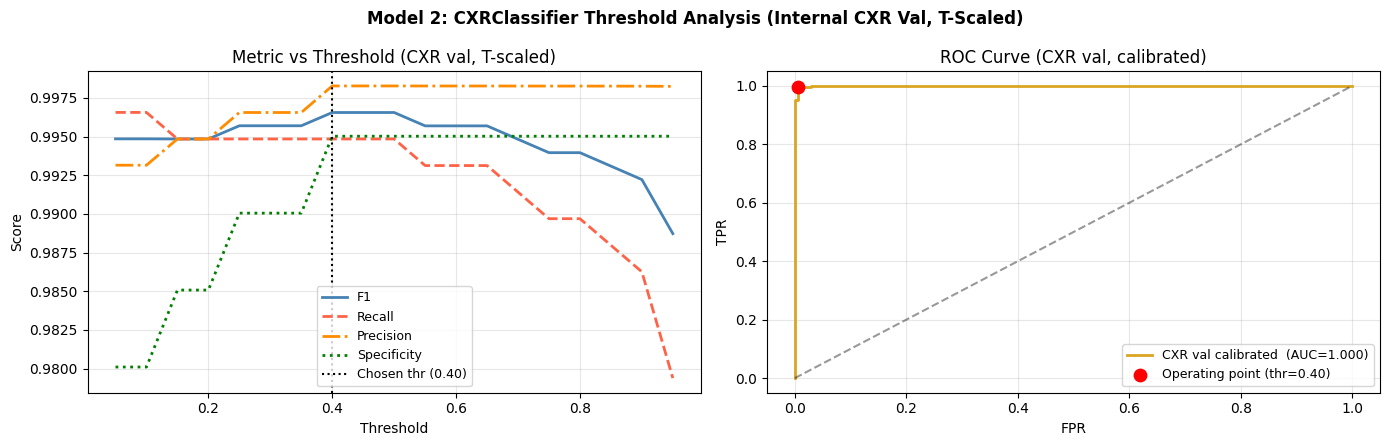

In [28]:
# Use temperature-calibrated logits for the threshold sweep.
# calibrated_logits = raw_logits / T* (already computed above)
y_val_small      = y_val_raw
logits_val_small = logits_val_calibrated   # calibrated

thresholds = np.linspace(0.05, 0.95, 19)
best_small_thresh_row = None
sweep_rows_small = []

for t in thresholds:
    met = compute_binary_metrics(y_val_small, logits_val_small, threshold=float(t))
    row = {"threshold": float(t), **{k: met[k] for k in
           ["f1", "recall", "precision", "specificity", "accuracy", "auroc"]}}
    sweep_rows_small.append(row)
    if best_small_thresh_row is None or row["f1"] > best_small_thresh_row["f1"]:
        best_small_thresh_row = row

small_threshold = best_small_thresh_row["threshold"]
print(f"CXRClassifier CXR val (calibrated) → best thr: {small_threshold:.2f}  "
      f"(F1={best_small_thresh_row['f1']:.3f}  "
      f"Recall={best_small_thresh_row['recall']:.3f}  "
      f"Precision={best_small_thresh_row['precision']:.3f}  "
      f"Spec={best_small_thresh_row['specificity']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Model 2: CXRClassifier Threshold Analysis (Internal CXR Val, T-Scaled)",
             fontsize=12, fontweight="bold")

thr_vals = [r["threshold"] for r in sweep_rows_small]
for metric, color, ls in [("f1","steelblue","-"), ("recall","tomato","--"),
                           ("precision","darkorange","-."), ("specificity","green",":")]:
    axes[0].plot(thr_vals, [r[metric] for r in sweep_rows_small],
                 label=metric.capitalize(), color=color, linestyle=ls, linewidth=2)
axes[0].axvline(small_threshold, color="black", linestyle=":", linewidth=1.5,
                label=f"Chosen thr ({small_threshold:.2f})")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("Metric vs Threshold (CXR val, T-scaled)")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

probs_small = sigmoid(logits_val_small)
fpr_s, tpr_s, _ = sk_roc_curve(y_val_small, probs_small)
auc_s = float(np.trapezoid(tpr_s, fpr_s))

axes[1].plot(fpr_s, tpr_s, color="goldenrod", linewidth=2,
             label=f"CXR val calibrated  (AUC={auc_s:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].scatter([1 - best_small_thresh_row["specificity"]],
                [best_small_thresh_row["recall"]],
                color="red", zorder=5, s=80,
                label=f"Operating point (thr={small_threshold:.2f})")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve (CXR val, calibrated)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"cxr_threshold_roc_{RUN_ID}.png"), dpi=200)
plt.show()


### CXRClassifier Test Evaluation

Evaluated on the held-out `test/` folder (624 images: 390 Cancer, 234 NORMAL)
at the threshold tuned on the internal CXR validation split.


In [29]:
# Apply temperature scaling to test logits before evaluation
@torch.no_grad()
def get_calibrated_eval(model, loader, device, temperature, threshold):
    """Evaluate with temperature-scaled logits."""
    model.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)
        all_logits.append(model(x).cpu().numpy())
        all_y.append(y.numpy().reshape(-1))
    raw_logits = np.concatenate(all_logits)
    cal_logits = raw_logits / temperature
    y_true     = np.concatenate(all_y).astype(int)
    return compute_binary_metrics(y_true, cal_logits, threshold=threshold)

cxr_test_small = get_calibrated_eval(small_model, cxr_test_loader, device,
                                      cxr_temperature, small_threshold)

print(f"Model 2 (CXRClassifier, Chest X-ray) test results  "
      f"[T*={cxr_temperature:.3f}  thr={small_threshold:.2f}]")
print(f"{'Dataset':22s}  {'AUROC':>6}  {'F1':>6}  {'Recall':>6}  {'Prec':>6}  {'Spec':>6}  {'Acc':>6}")
print("  " + "-" * 65)
for name, m in [("Chest X-ray (CXR)", cxr_test_small)]:
    def _f(v): return f"{v:.3f}" if v is not None else "N/A"
    print(f"  {name:22s}  {_f(m['auroc']):>6}  {_f(m['f1']):>6}  "
          f"{_f(m['recall']):>6}  {_f(m['precision']):>6}  "
          f"{_f(m['specificity']):>6}  {_f(m['accuracy']):>6}")


Model 2 (CXRClassifier, Chest X-ray) test results  [T*=0.467  thr=0.40]
Dataset                  AUROC      F1  Recall    Prec    Spec     Acc
  -----------------------------------------------------------------
  Chest X-ray (CXR)        0.886   0.887   0.995   0.800   0.585   0.841


### External CXR Generalization Evaluation (Optional)

To test CXRClassifier generalization on an independent dataset, point
`EXTERNAL_CXR_ROOT` to a folder with `Cancer/` and `NORMAL/` sub-folders.
If the path does not exist the cell prints a message and skips gracefully.

In [30]:
# ── External CXR dataset evaluation (point to your data folder) ───────────────
# Supported structure:  <EXTERNAL_CXR_ROOT>/Cancer/*.jpg  and  .../NORMAL/*.jpg
EXTERNAL_CXR_ROOT = os.path.join(REPO_ROOT, "data", "external_cxr")

if os.path.isdir(EXTERNAL_CXR_ROOT):
    import torchvision.transforms as tvT
    ext_eval_transform = tvT.Compose([
        tvT.Grayscale(num_output_channels=1),
        tvT.Resize((224, 224)),
        tvT.ToTensor(),
        tvT.Normalize(mean=[0.5], std=[0.5]),
    ])
    ext_samples = ChestXrayCancerDataset.collect_samples(EXTERNAL_CXR_ROOT, split=None)
    if ext_samples:
        ext_ds     = ChestXrayCancerDataset(ext_samples, transform=ext_eval_transform)
        ext_loader = DataLoader(ext_ds, batch_size=32, shuffle=False,
                                collate_fn=cxr_collate_fn,
                                num_workers=cfg.num_workers)
        ext_results = get_calibrated_eval(small_model, ext_loader, device,
                                           cxr_temperature, small_threshold)
        print("External CXR results:")
        for k, v in ext_results.items():
            if v is not None:
                print(f"  {k:15s}: {v:.4f}")
    else:
        print(f"No images found in {EXTERNAL_CXR_ROOT}. Skipping.")
else:
    print(f"External CXR dataset not found at: {EXTERNAL_CXR_ROOT}")
    print("To evaluate, add a folder with Cancer/ and NORMAL/ sub-folders at that path.")


External CXR dataset not found at: /Users/toriav/Desktop/Erem/CMPE 401/lung-nodule-3d/data/external_cxr
To evaluate, add a folder with Cancer/ and NORMAL/ sub-folders at that path.


---

## Combined Results

Unified reporting across both models and all three datasets.

| Model | Datasets | Threshold tuned on |
|---|---|---|
| Deep3DCNN | NoduleMNIST3D · LUNA16 | NoduleMNIST3D val (genuine 3D) |
| CXRClassifier | Chest X-ray (CXR) | Internal CXR val split (15% of train) |

Each model is evaluated only on the domain it was trained for.
This eliminates cross-domain calibration interference and ensures the
operating threshold reflects the actual data distribution the model will see
in deployment.


## Confusion Matrices

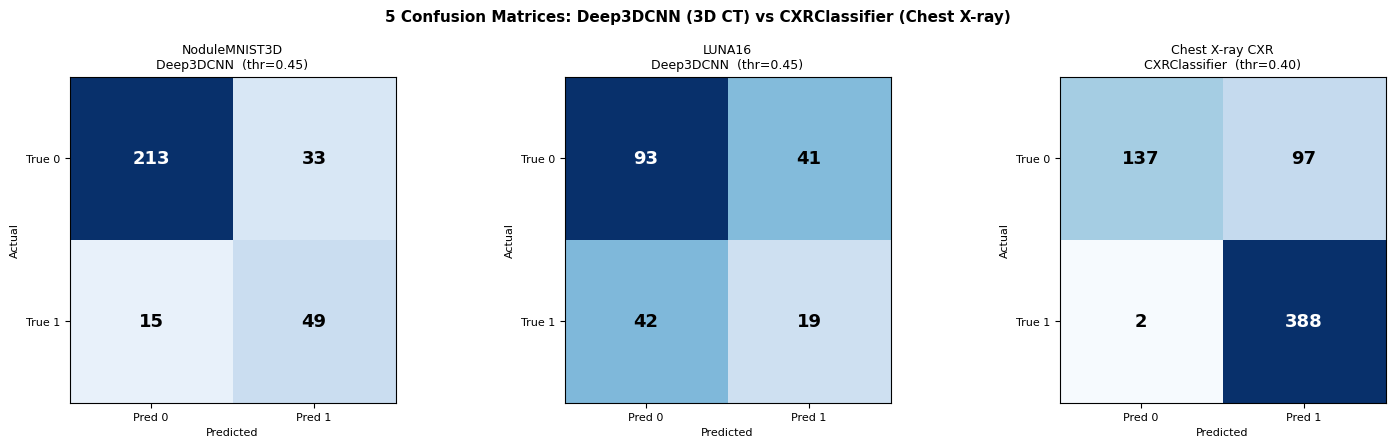

In [31]:
# Gather all results for combined reporting
dataset_results_all = [
    ("NoduleMNIST3D",    nodule_test_deep,  "Deep3DCNN",  deep_threshold),
    ("LUNA16",           luna16_test_deep,  "Deep3DCNN",  deep_threshold),
    ("Chest X-ray CXR",  cxr_test_small,    "CXRClassifier", small_threshold),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("5 Confusion Matrices: Deep3DCNN (3D CT) vs CXRClassifier (Chest X-ray)",
             fontsize=11, fontweight="bold")

for ax, (name, met, model_name, thr) in zip(axes, dataset_results_all):
    cm = np.array(met["confusion_matrix"])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"], fontsize=8)
    ax.set_title(f"{name}\n{model_name}  (thr={thr:.2f})", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8); ax.set_ylabel("Actual", fontsize=8)
    thresh_cm = cm.max() * 0.55
    for ii, jj in itertools.product(range(2), range(2)):
        ax.text(jj, ii, f"{cm[ii,jj]}", ha="center", va="center",
                color="white" if cm[ii,jj] > thresh_cm else "black",
                fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"confusion_matrices_tuned_{RUN_ID}.png"), dpi=200)
plt.show()


## Logistic Regression Baseline
### Flattened voxels, NoduleMNIST3D only

In [32]:
# Trained on the same NoduleMNIST3D train/val/test split used across all trials.
def flatten_dataset(ds):
    X, y = [], []
    for i in range(len(ds)):
        x_i, y_i = ds[i]
        X.append(np.array(x_i).astype(np.float32).reshape(-1))
        y.append(int(np.array(y_i).reshape(-1)[0]))
    return np.stack(X), np.array(y)

X_train_lr, y_train_lr = flatten_dataset(train_ds)
X_test_lr,  y_test_lr  = flatten_dataset(test_ds)

clf = make_pipeline(StandardScaler(),
                    LogisticRegression(max_iter=2000, class_weight="balanced"))
clf.fit(X_train_lr, y_train_lr)

lr_metrics = compute_binary_metrics(y_test_lr, clf.decision_function(X_test_lr), threshold=0.5)
print("LogReg baseline (NoduleMNIST3D test, thr=0.50):")
for k, v in lr_metrics.items():
    if k != "confusion_matrix":
        print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

with open(metrics_path, "r") as f:
    m_all = json.load(f)
m_all.update({
    "deep_threshold":       deep_threshold,
    "small_threshold":      small_threshold,
    "test_nodule_deep":     nodule_test_deep,
    "test_luna16_deep":     luna16_test_deep,
    "test_cxr_small":       cxr_test_small,
    "logreg_baseline_test": lr_metrics,
})
with open(metrics_path, "w") as f:
    json.dump(m_all, f, indent=2)


LogReg baseline (NoduleMNIST3D test, thr=0.50):
  auroc: 0.823
  f1: 0.538
  accuracy: 0.806
  precision: 0.530
  recall: 0.547
  specificity: 0.874


## Results Summary

Final performance table across both models and all datasets.

- **Blue rows:** Deep3DCNN on genuine 3D CT data (NoduleMNIST3D + LUNA16)
- **Yellow rows:** CXRClassifier (ResNet-18) on chest X-ray data
- **Grey row:** Logistic Regression baseline (NoduleMNIST3D flat voxels)


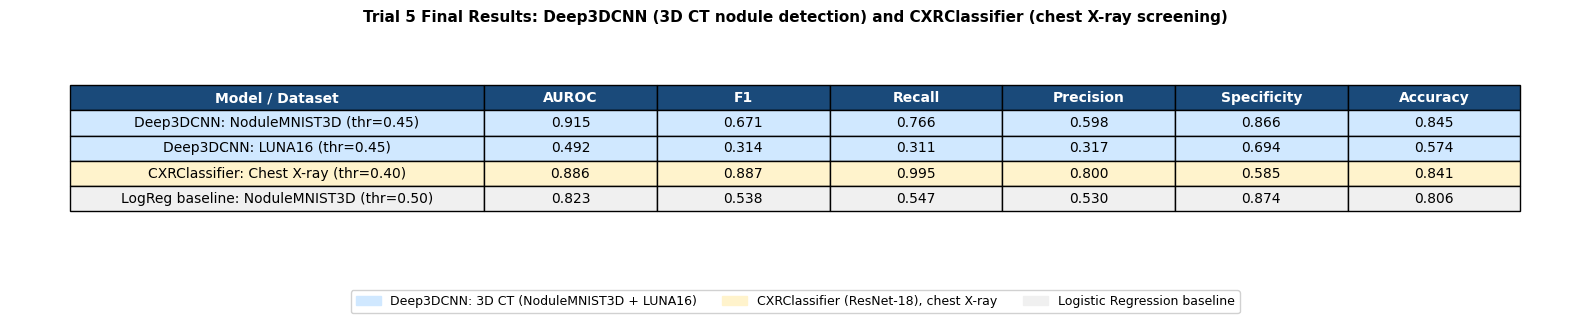

In [33]:
def fmt(v):
    return "N/A" if v is None else f"{v:.3f}"

def row_from(label, met):
    return [label,
            fmt(met.get("auroc")),  fmt(met.get("f1")),
            fmt(met.get("recall")), fmt(met.get("precision")),
            fmt(met.get("specificity")), fmt(met.get("accuracy"))]

rows = [
    row_from(f"Deep3DCNN: NoduleMNIST3D (thr={deep_threshold:.2f})",     nodule_test_deep),
    row_from(f"Deep3DCNN: LUNA16 (thr={deep_threshold:.2f})",             luna16_test_deep),
    row_from(f"CXRClassifier: Chest X-ray (thr={small_threshold:.2f})",   cxr_test_small),
    row_from("LogReg baseline: NoduleMNIST3D (thr=0.50)",                  lr_metrics),
]

row_colors = [
    ["#d0e8ff"] * 7,  # Deep / NoduleMNIST3D
    ["#d0e8ff"] * 7,  # Deep / LUNA16
    ["#fff3cc"] * 7,  # CXR
    ["#f0f0f0"] * 7,  # LogReg
]

col_labels = ["Model / Dataset", "AUROC", "F1", "Recall", "Precision", "Specificity", "Accuracy"]

fig, ax = plt.subplots(figsize=(16, 3.5))
ax.axis("off")
ax.set_title(
    "Trial 5 Final Results: Deep3DCNN (3D CT nodule detection) and CXRClassifier (chest X-ray screening)",
    fontsize=11, fontweight="bold", pad=14,
)

table = ax.table(
    cellText=rows, colLabels=col_labels,
    cellColours=row_colors,
    loc="center",
    cellLoc="center",
    colWidths=[0.24, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.9)

for j in range(len(col_labels)):
    table[(0, j)].set_facecolor("#1a4a7a")
    table[(0, j)].set_text_props(color="white", fontweight="bold")

patches = [
    mpatches.Patch(color="#d0e8ff", label="Deep3DCNN: 3D CT (NoduleMNIST3D + LUNA16)"),
    mpatches.Patch(color="#fff3cc", label="CXRClassifier (ResNet-18), chest X-ray"),
    mpatches.Patch(color="#f0f0f0", label="Logistic Regression baseline"),
]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, -0.30),
          ncol=3, fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png"), dpi=300, bbox_inches="tight")
plt.show()
